# Semantic Book Intelligence Research Lab
## Notebook 05 — Transformer Sentence Embeddings and Controlled Comparison

**Primary research question**

> Do pretrained dense sentence embeddings improve weak multi-label genre classification and semantic-neighbor quality beyond the frozen classical baseline when evaluated on the identical eligible cohort and work-group split?

**Frozen classical reference:** Word + Character TF-IDF with a class-balanced Linear SVM; validation Macro F1 = 0.5626 and final test Macro F1 = 0.5681.

**Primary metric:** Macro F1, because each included genre should contribute equally despite strong label imbalance.

**Supporting evidence:** Grouped cross-validation variability, Micro and weighted F1, macro average precision, subset accuracy, Hamming loss, per-genre precision/recall/F1, error slices, semantic-neighbor overlap, runtime, and artifact size.

This notebook compares fixed pretrained encoders as reusable feature generators. It does not fine-tune transformers, expand to 25,000 books, build clustering or topic models, create a vector database, or implement a production search service.

## 1. Imports, configuration, and reproducibility

In [3]:
from __future__ import annotations

from html import unescape
from pathlib import Path
from time import perf_counter
import gc
import hashlib
import json
import re
import sys

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

import huggingface_hub
# Keep this import ahead of direct sklearn/torch imports for stable macOS Conda OpenMP initialization.
import sentence_transformers
import sklearn
import torch
import transformers
from sentence_transformers import SentenceTransformer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    hamming_loss,
    make_scorer,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, GroupKFold, cross_val_predict
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, normalize
from sklearn.svm import LinearSVC

# Centralize experimental controls so every rerun uses the same compute and decision rules.
RANDOM_STATE = 42
CV_SPLITS = 5
N_JOBS = -1
ENCODING_BATCH_SIZE = 32
NEIGHBOR_K = 5
MIN_SLICE_BOOKS = 20
MATERIAL_MACRO_F1_GAIN = 0.01
CACHE_SCHEMA_VERSION = 1

TARGET_GENRES = [
    "fiction",
    "history, historical fiction, biography",
    "romance",
    "non-fiction",
    "fantasy, paranormal",
    "mystery, thriller, crime",
    "young-adult",
    "children",
    "comics, graphic",
    "poetry",
]

# Resolve paths from either the repository root or notebooks folder and keep artifacts stable.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "figures" / "notebook05"
MODELS_DIR = PROJECT_ROOT / "models" / "notebook05"

for directory in [PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

FILES = {
    "books": INTERIM_DIR / "books_sample.parquet",
    "text_features": PROCESSED_DIR / "book_text_features_v1.parquet",
    "split_manifest": PROCESSED_DIR / "research_split_v1.parquet",
    "lsa_features": PROCESSED_DIR / "book_lsa_features_v1.parquet",
    "classical_comparison": REPORTS_DIR / "notebook04_model_comparison.csv",
    "classical_test": REPORTS_DIR / "notebook04_final_test_metrics.csv",
    "classical_per_genre": REPORTS_DIR / "notebook04_per_genre_metrics.csv",
}

# Prefer available acceleration while recording the selected device for reproducibility.
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_colwidth", 90)
sns.set_theme(style="whitegrid", context="notebook")

# Capture package versions because model loading and tokenization can change across releases.
version_summary = pd.DataFrame(
    {
        "library": [
            "Python",
            "NumPy",
            "pandas",
            "scikit-learn",
            "PyTorch",
            "Transformers",
            "Sentence Transformers",
            "Hugging Face Hub",
            "Matplotlib",
            "seaborn",
        ],
        "version": [
            sys.version.split()[0],
            np.__version__,
            pd.__version__,
            sklearn.__version__,
            torch.__version__,
            transformers.__version__,
            sentence_transformers.__version__,
            huggingface_hub.__version__,
            matplotlib.__version__,
            sns.__version__,
        ],
    }
)
display(version_summary)
print(f"Embedding device: {DEVICE}; encoding batch size: {ENCODING_BATCH_SIZE}")

,library,version
0,Python,3.12.13
1,NumPy,2.5.1
2,pandas,3.0.3
3,scikit-learn,1.9.0
4,PyTorch,2.13.0
5,Transformers,5.15.0
6,Sentence Transformers,5.7.0
7,Hugging Face Hub,1.27.0
8,Matplotlib,3.11.1
9,seaborn,0.13.2


Embedding device: mps; encoding batch size: 32


## 2. Validate and reconstruct the frozen Notebook 04 cohort

In [4]:
# Fail early if any frozen Notebook 04 input is missing before reconstruction begins.
file_status = pd.DataFrame(
    [
        {
            "artifact": name,
            "path": str(artifact_path),
            "exists": artifact_path.exists(),
            "size_mb": round(artifact_path.stat().st_size / (1024**2), 3)
            if artifact_path.exists()
            else np.nan,
        }
        for name, artifact_path in FILES.items()
    ]
)
display(file_status)

missing_files = file_status.loc[~file_status["exists"], "path"].tolist()
if missing_files:
    raise FileNotFoundError(
        "Notebook 05 requires completed Notebook 04 artifacts:\n" + "\n".join(missing_files)
    )

# Load prior artifacts once and normalize identifiers before any validated joins.
books = pd.read_parquet(FILES["books"])
text_features = pd.read_parquet(FILES["text_features"])
split_manifest = pd.read_parquet(FILES["split_manifest"])
lsa_features = pd.read_parquet(FILES["lsa_features"])
classical_comparison = pd.read_csv(FILES["classical_comparison"])
classical_test = pd.read_csv(FILES["classical_test"])
classical_per_genre = pd.read_csv(FILES["classical_per_genre"])

for frame in [books, text_features, split_manifest, lsa_features]:
    frame["book_id"] = frame["book_id"].astype("string")

if not books["book_id"].is_unique:
    raise ValueError("books_sample.parquet must contain one row per book_id.")
if not text_features["book_id"].is_unique:
    raise ValueError("book_text_features_v1.parquet must contain one row per eligible book_id.")
if not split_manifest["book_id"].is_unique:
    raise ValueError("research_split_v1.parquet must contain one row per eligible book_id.")

required_text_columns = {
    "book_id",
    "work_id",
    "title",
    "split",
    "text_word_count",
    "weak_genres",
}
required_split_columns = {"book_id", "work_group", "split"}

if not required_text_columns.issubset(text_features.columns):
    raise KeyError(
        f"Text feature artifact is missing: {sorted(required_text_columns - set(text_features.columns))}"
    )
if not required_split_columns.issubset(split_manifest.columns):
    raise KeyError(
        f"Split artifact is missing: {sorted(required_split_columns - set(split_manifest.columns))}"
    )

HTML_TAG_PATTERN = re.compile(r"<[^>]+>")
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+", flags=re.IGNORECASE)
WHITESPACE_PATTERN = re.compile(r"\s+")


# Apply conservative cleanup only; retain the lexical content expected by pretrained encoders.
def normalize_description(value: object) -> str:
    if pd.isna(value):
        return ""
    text = unescape(str(value))
    text = HTML_TAG_PATTERN.sub(" ", text)
    text = URL_PATTERN.sub(" ", text)
    return WHITESPACE_PATTERN.sub(" ", text).strip()


# Reconstruct the exact eligible cohort through one-to-one joins rather than resampling.
analysis = (
    text_features.merge(
        books[["book_id", "description", "language_code"]],
        on="book_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        split_manifest[["book_id", "work_group", "split"]].rename(
            columns={"split": "manifest_split"}
        ),
        on="book_id",
        how="left",
        validate="one_to_one",
    )
)

if analysis["description"].isna().any():
    raise ValueError("Every Notebook 04 eligible book must retain its source description.")
if not analysis["split"].equals(analysis["manifest_split"]):
    raise ValueError("Text features and research_split_v1 disagree on split assignment.")

analysis = analysis.drop(columns="manifest_split")
analysis["clean_description"] = analysis["description"].map(normalize_description)
analysis["genres"] = analysis["weak_genres"].str.split(" | ", regex=False).map(tuple)

observed_genres = set().union(*analysis["genres"])
unknown_genres = sorted(observed_genres - set(TARGET_GENRES))
if unknown_genres:
    raise ValueError(f"Unexpected labels outside the frozen Notebook 04 target set: {unknown_genres}")

# Binarize labels in the frozen genre order so every metric and artifact stays aligned.
label_binarizer = MultiLabelBinarizer(classes=TARGET_GENRES)
label_matrix = label_binarizer.fit_transform(analysis["genres"])

ENGLISH_CODES = {"en", "eng", "en-us", "en-gb", "en-ca", "en-au"}


def normalize_language_code(value: object) -> str:
    if pd.isna(value) or not str(value).strip():
        return "unknown"
    return str(value).strip().casefold()


analysis["language_code_clean"] = analysis["language_code"].map(normalize_language_code)
analysis["language_group"] = np.select(
    [
        analysis["language_code_clean"].isin(ENGLISH_CODES),
        analysis["language_code_clean"].eq("unknown"),
    ],
    ["English", "Unknown"],
    default="Non-English",
)

# Treat split sizes and work-group counts as hard guards against accidental experiment drift.
expected_split_counts = {"train": 2446, "validation": 525, "test": 526}
actual_split_counts = analysis["split"].value_counts().to_dict()
if actual_split_counts != expected_split_counts:
    raise ValueError(
        f"Frozen split counts changed: expected {expected_split_counts}, found {actual_split_counts}"
    )
if len(analysis) != 3497 or analysis["work_group"].nunique() != 3480:
    raise ValueError("Notebook 05 must use the exact 3,497-book / 3,480-work Notebook 04 cohort.")

# Read benchmark values from Notebook 04 artifacts instead of duplicating them in code.
classical_validation_macro_f1 = float(
    classical_comparison.loc[
        (classical_comparison["representation"] == "Word + Character TF-IDF")
        & (classical_comparison["model"] == "Linear SVM"),
        "validation_macro_f1",
    ].iloc[0]
)
classical_test_macro_f1 = float(classical_test["macro_f1"].iloc[0])

cohort_summary = pd.DataFrame(
    {
        "metric": [
            "eligible_books",
            "work_groups",
            "training_books",
            "validation_books",
            "test_books",
            "included_genres",
            "classical_validation_macro_f1",
            "classical_test_macro_f1",
        ],
        "value": [
            len(analysis),
            analysis["work_group"].nunique(),
            actual_split_counts["train"],
            actual_split_counts["validation"],
            actual_split_counts["test"],
            len(TARGET_GENRES),
            classical_validation_macro_f1,
            classical_test_macro_f1,
        ],
    }
)
display(cohort_summary)

,artifact,path,exists,size_mb
0,books,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/books_s...,True,3.292
1,text_features,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/processed/book_...,True,0.299
2,split_manifest,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/processed/resea...,True,0.095
3,lsa_features,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/processed/book_...,True,1.949
4,classical_comparison,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook04_m...,True,0.003
5,classical_test,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook04_f...,True,0.000
6,classical_per_genre,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook04_p...,True,0.001


,metric,value
0,eligible_books,3497.000000
1,work_groups,3480.000000
2,training_books,2446.000000
3,validation_books,525.000000
4,test_books,526.000000
5,included_genres,10.000000
6,classical_validation_macro_f1,0.562595
7,classical_test_macro_f1,0.568133


,books,median_words,share
language_group,,,
English,1488,141.0,0.4255
Non-English,580,111.5,0.1659
Unknown,1429,129.0,0.4086


,language_group,language_code_clean,books,median_words
3,English,eng,1192,140.5
2,English,en-us,175,146.0
1,English,en-gb,104,134.5
0,English,en-ca,17,194.0
39,Non-English,spa,77,125.0
20,Non-English,ita,71,140.0
15,Non-English,ger,49,106.0
14,Non-English,fre,36,102.5
19,Non-English,ind,36,87.0
34,Non-English,por,36,130.5


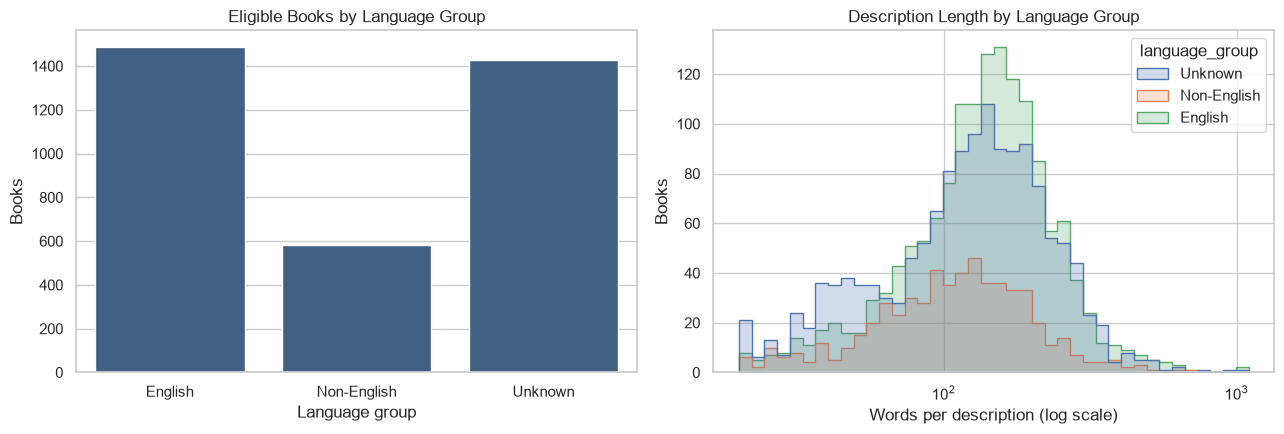


### Result interpretation — frozen cohort and language coverage

- Notebook 05 exactly reproduces the 3,497-book, 3,480-work cohort and 2,446/525/526 split from Notebook 04; the classical validation and test benchmarks are 0.5626 and 0.5681 Macro F1.
- Non-English language codes account for 16.6% of eligible books and unknown codes account for 40.9%. These groups justify a multilingual encoder and explicit language-slice reporting.
- Language codes are metadata quality signals rather than verified language detection. Later slice differences should be treated as diagnostic associations, not causal effects.


In [5]:
# Profile detailed language codes and broad groups to expose coverage and sample-size limits.
language_profile = (
    analysis.groupby(["language_group", "language_code_clean"], observed=True)
    .agg(books=("book_id", "size"), median_words=("text_word_count", "median"))
    .reset_index()
    .sort_values(["language_group", "books"], ascending=[True, False])
)

language_group_summary = (
    analysis.groupby("language_group", observed=True)
    .agg(books=("book_id", "size"), median_words=("text_word_count", "median"))
    .reindex(["English", "Non-English", "Unknown"])
)
language_group_summary["share"] = language_group_summary["books"] / len(analysis)

display(language_group_summary.round(4))
display(language_profile.head(12))

# Pair group counts with description lengths because both affect multilingual comparisons.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(
    data=language_group_summary.reset_index(),
    x="language_group",
    y="books",
    color="#35618f",
    ax=axes[0],
)
axes[0].set_title("Eligible Books by Language Group")
axes[0].set_xlabel("Language group")
axes[0].set_ylabel("Books")

sns.histplot(
    data=analysis,
    x="text_word_count",
    hue="language_group",
    bins=40,
    log_scale=(True, False),
    element="step",
    common_norm=False,
    ax=axes[1],
)
axes[1].set_title("Description Length by Language Group")
axes[1].set_xlabel("Words per description (log scale)")
axes[1].set_ylabel("Books")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "language_and_description_profile.png", dpi=160, bbox_inches="tight")
plt.show()

non_english_share = language_group_summary.loc["Non-English", "share"]
unknown_share = language_group_summary.loc["Unknown", "share"]

display(
    Markdown(
        f"""
### Result interpretation — frozen cohort and language coverage

- Notebook 05 exactly reproduces the 3,497-book, 3,480-work cohort and 2,446/525/526 split from Notebook 04; the classical validation and test benchmarks are {classical_validation_macro_f1:.4f} and {classical_test_macro_f1:.4f} Macro F1.
- Non-English language codes account for {non_english_share:.1%} of eligible books and unknown codes account for {unknown_share:.1%}. These groups justify a multilingual encoder and explicit language-slice reporting.
- Language codes are metadata quality signals rather than verified language detection. Later slice differences should be treated as diagnostic associations, not causal effects.
"""
    )
)

## 3. Pretrained encoder registry and long-text policy

The comparison is intentionally bounded to two 384-dimensional encoders:

- [all-MiniLM-L6-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2), a compact English sentence encoder.
- [multilingual-e5-small](https://huggingface.co/intfloat/multilingual-e5-small), a multilingual encoder whose model card instructs feature-extraction tasks to use the `query:` prefix.

Exact repository revisions are pinned below. Long descriptions use deterministic token-aware chunking; normalized chunk vectors are averaged and normalized again. This prevents silent loss of later description content while keeping the policy fixed before evaluation.

In [6]:
# Freeze encoder revisions, dimensions, and prefixes before viewing any model performance.
MODEL_CONFIGS = [
    {
        "embedding_name": "MiniLM English",
        "slug": "minilm_english",
        "model_id": "sentence-transformers/all-MiniLM-L6-v2",
        "revision": "1110a243fdf4706b3f48f1d95db1a4f5529b4d41",
        "text_prefix": "",
        "expected_dimension": 384,
        "language_scope": "English",
    },
    {
        "embedding_name": "Multilingual E5 Small",
        "slug": "multilingual_e5_small",
        "model_id": "intfloat/multilingual-e5-small",
        "revision": "fd1525a9fd15316a2d503bf26ab031a61d056e98",
        "text_prefix": "query: ",
        "expected_dimension": 384,
        "language_scope": "Multilingual",
    },
]

# Display the compact registry as an auditable record of the planned representation comparison.
model_registry = pd.DataFrame(MODEL_CONFIGS)[
    [
        "embedding_name",
        "model_id",
        "revision",
        "expected_dimension",
        "language_scope",
        "text_prefix",
    ]
]
display(model_registry)

,embedding_name,model_id,revision,expected_dimension,language_scope,text_prefix
0,MiniLM English,sentence-transformers/all-MiniLM-L6-v2,1110a243fdf4706b3f48f1d95db1a4f5529b4d41,384,English,
1,Multilingual E5 Small,intfloat/multilingual-e5-small,fd1525a9fd15316a2d503bf26ab031a61d056e98,384,Multilingual,query:


## 4. Generate or load validated transformer embedding caches

In [7]:
# Hash ordered IDs and cleaned text so stale caches cannot survive a corpus change.
def corpus_fingerprint(frame: pd.DataFrame) -> str:
    hasher = hashlib.sha256()
    for book_id, description in frame[["book_id", "clean_description"]].itertuples(index=False):
        hasher.update(str(book_id).encode("utf-8"))
        hasher.update(b"\0")
        hasher.update(description.encode("utf-8"))
        hasher.update(b"\n")
    return hasher.hexdigest()


CORPUS_FINGERPRINT = corpus_fingerprint(analysis)


# Enforce unit-length vectors for consistent cosine geometry and classifier inputs.
def normalize_embedding_rows(matrix: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    if (norms == 0).any():
        raise ValueError("Embedding generation produced at least one zero vector.")
    return (matrix / norms).astype(np.float32)


# Split by tokenizer tokens, not characters, so every chunk respects the model window.
def prepare_token_chunks(
    texts: list[str],
    tokenizer: object,
    max_sequence_length: int,
    text_prefix: str,
) -> tuple[list[str], np.ndarray, np.ndarray]:
    prefix_ids = tokenizer.encode(text_prefix, add_special_tokens=False)
    special_tokens = tokenizer.num_special_tokens_to_add(pair=False)
    available_body_tokens = max_sequence_length - len(prefix_ids) - special_tokens

    if available_body_tokens < 32:
        raise ValueError("Model sequence length leaves too little room for description text.")

    # Track chunk ownership so vectors can be aggregated back to the original book order.
    chunk_texts: list[str] = []
    owners: list[int] = []
    raw_token_counts: list[int] = []

    for owner, text in enumerate(texts):
        body_ids = tokenizer.encode(text, add_special_tokens=False)
        raw_token_counts.append(len(prefix_ids) + len(body_ids) + special_tokens)
        token_chunks = [
            body_ids[start : start + available_body_tokens]
            for start in range(0, max(len(body_ids), 1), available_body_tokens)
        ]

        for token_chunk in token_chunks:
            chunk_body = tokenizer.decode(
                token_chunk,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=True,
            )
            chunk_texts.append(f"{text_prefix}{chunk_body}".strip())
            owners.append(owner)

    return (
        chunk_texts,
        np.asarray(owners, dtype=np.int64),
        np.asarray(raw_token_counts, dtype=np.int32),
    )


# Reuse a cache only when its model, text policy, corpus fingerprint, and row count match.
def cache_is_valid(
    manifest: dict[str, object],
    config: dict[str, object],
    expected_rows: int,
) -> bool:
    return all(
        [
            manifest.get("cache_schema_version") == CACHE_SCHEMA_VERSION,
            manifest.get("model_id") == config["model_id"],
            manifest.get("revision") == config["revision"],
            manifest.get("text_prefix") == config["text_prefix"],
            manifest.get("corpus_fingerprint") == CORPUS_FINGERPRINT,
            manifest.get("rows") == expected_rows,
            manifest.get("long_text_policy") == "token_chunk_mean",
        ]
    )


# Prefer a validated artifact; otherwise generate embeddings under the fixed encoder policy.
def load_or_create_embeddings(
    config: dict[str, object],
    frame: pd.DataFrame,
) -> tuple[np.ndarray, dict[str, object]]:
    cache_path = PROCESSED_DIR / f"book_transformer_embeddings_{config['slug']}_v1.parquet"
    manifest_path = MODELS_DIR / f"{config['slug']}_embedding_manifest_v1.json"

    if cache_path.exists() and manifest_path.exists():
        with manifest_path.open("r", encoding="utf-8") as handle:
            manifest = json.load(handle)

        if cache_is_valid(manifest, config, len(frame)):
            cached = pd.read_parquet(cache_path)
            if not cached["book_id"].astype("string").equals(frame["book_id"].reset_index(drop=True)):
                raise ValueError(f"Cached book order does not match the frozen cohort: {cache_path}")

            embedding_columns = [
                column for column in cached.columns if column.startswith("embedding_")
            ]
            matrix = cached[embedding_columns].to_numpy(dtype=np.float32)
            if matrix.shape[1] != config["expected_dimension"]:
                raise ValueError(f"Unexpected cached embedding width for {config['embedding_name']}.")

            manifest = {
                **manifest,
                "cache_status": "loaded",
                "cache_path": str(cache_path),
                "cache_size_mb": cache_path.stat().st_size / (1024**2),
            }
            return matrix, manifest

    # Pin the exact repository revision and disallow model-supplied remote execution code.
    started_at = perf_counter()
    model = SentenceTransformer(
        config["model_id"],
        revision=config["revision"],
        device=DEVICE,
        trust_remote_code=False,
    )
    max_sequence_length = int(model.max_seq_length)

    chunk_texts, owners, raw_token_counts = prepare_token_chunks(
        frame["clean_description"].tolist(),
        model.tokenizer,
        max_sequence_length,
        str(config["text_prefix"]),
    )

    chunk_embeddings = model.encode(
        chunk_texts,
        batch_size=ENCODING_BATCH_SIZE,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32)

    # Average normalized chunk vectors per book, then renormalize the final book vectors.
    book_embeddings = np.zeros(
        (len(frame), chunk_embeddings.shape[1]),
        dtype=np.float32,
    )
    np.add.at(book_embeddings, owners, chunk_embeddings)
    chunk_counts = np.bincount(owners, minlength=len(frame)).astype(np.float32)
    book_embeddings /= chunk_counts[:, None]
    book_embeddings = normalize_embedding_rows(book_embeddings)

    if book_embeddings.shape[1] != config["expected_dimension"]:
        raise ValueError(
            f"{config['embedding_name']} produced {book_embeddings.shape[1]} dimensions; "
            f"expected {config['expected_dimension']}."
        )

    embedding_columns = [
        f"embedding_{index:03d}" for index in range(book_embeddings.shape[1])
    ]
    # Persist identifiers beside vectors so future loads can verify row-level alignment.
    cache_frame = pd.DataFrame(book_embeddings, columns=embedding_columns)
    cache_frame.insert(0, "split", frame["split"].to_numpy())
    cache_frame.insert(0, "work_id", frame["work_id"].to_numpy())
    cache_frame.insert(0, "book_id", frame["book_id"].to_numpy())
    cache_frame.to_parquet(cache_path, index=False)

    elapsed_seconds = perf_counter() - started_at
    # Record coverage, runtime, device, and generation settings with each cached representation.
    manifest = {
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "embedding_name": config["embedding_name"],
        "model_id": config["model_id"],
        "revision": config["revision"],
        "text_prefix": config["text_prefix"],
        "language_scope": config["language_scope"],
        "long_text_policy": "token_chunk_mean",
        "corpus_fingerprint": CORPUS_FINGERPRINT,
        "rows": len(frame),
        "embedding_dimension": book_embeddings.shape[1],
        "max_sequence_length": max_sequence_length,
        "descriptions_over_single_window": int((raw_token_counts > max_sequence_length).sum()),
        "multi_chunk_rate": float((raw_token_counts > max_sequence_length).mean()),
        "total_chunks": int(len(chunk_texts)),
        "maximum_raw_tokens": int(raw_token_counts.max()),
        "generation_seconds": elapsed_seconds,
        "device": DEVICE,
        "batch_size": ENCODING_BATCH_SIZE,
    }
    with manifest_path.open("w", encoding="utf-8") as handle:
        json.dump(manifest, handle, indent=2)

    manifest = {
        **manifest,
        "cache_status": "generated",
        "cache_path": str(cache_path),
        "cache_size_mb": cache_path.stat().st_size / (1024**2),
    }

    del model, chunk_embeddings
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE == "mps" and hasattr(torch.mps, "empty_cache"):
        torch.mps.empty_cache()

    return book_embeddings, manifest

In [8]:
# Generate both encoders in identical cohort order; each helper call validates cache reuse.
embedding_matrices: dict[str, np.ndarray] = {}
embedding_manifests: list[dict[str, object]] = []

for config in MODEL_CONFIGS:
    matrix, manifest = load_or_create_embeddings(config, analysis)
    embedding_matrices[config["embedding_name"]] = matrix
    embedding_manifests.append(manifest)
    print(
        f"{config['embedding_name']}: {manifest['cache_status']}; "
        f"{matrix.shape[0]:,} books x {matrix.shape[1]:,} dimensions; "
        f"{manifest['multi_chunk_rate']:.1%} multi-chunk."
    )

# Keep the notebook output concise while exposing the key artifact and coverage diagnostics.
embedding_inventory = pd.DataFrame(embedding_manifests)[
    [
        "embedding_name",
        "model_id",
        "revision",
        "rows",
        "embedding_dimension",
        "max_sequence_length",
        "descriptions_over_single_window",
        "multi_chunk_rate",
        "total_chunks",
        "maximum_raw_tokens",
        "generation_seconds",
        "cache_status",
        "cache_size_mb",
        "device",
    ]
]
display(embedding_inventory.round(4))

most_chunked = embedding_inventory.sort_values("multi_chunk_rate", ascending=False).iloc[0]
display(
    Markdown(
        f"""
### Result interpretation — token coverage and embedding artifacts

- Both encoders produce {int(embedding_inventory['embedding_dimension'].min())}-dimensional, unit-normalized book vectors aligned to the frozen cohort.
- **{most_chunked['embedding_name']}** has the larger multi-chunk rate at {most_chunked['multi_chunk_rate']:.1%}. Chunk averaging ensures those books retain text beyond a single model window instead of being silently truncated.
- A cache status of `generated` means the pinned model ran during this execution; `loaded` means a fingerprint-validated prior artifact was reused. Runtime comparisons should use the recorded original generation time rather than cache-loading time.
"""
    )
)

MiniLM English: loaded; 3,497 books x 384 dimensions; 26.6% multi-chunk.
Multilingual E5 Small: loaded; 3,497 books x 384 dimensions; 3.3% multi-chunk.


,embedding_name,model_id,revision,rows,embedding_dimension,max_sequence_length,descriptions_over_single_window,multi_chunk_rate,total_chunks,maximum_raw_tokens,generation_seconds,cache_status,cache_size_mb,device
0,MiniLM English,sentence-transformers/all-MiniLM-L6-v2,1110a243fdf4706b3f48f1d95db1a4f5529b4d41,3497,384,256,929,0.2657,4601,1875,14.2719,loaded,7.3213,mps
1,Multilingual E5 Small,intfloat/multilingual-e5-small,fd1525a9fd15316a2d503bf26ab031a61d056e98,3497,384,512,116,0.0332,3628,2064,23.4767,loaded,7.3210,mps



### Result interpretation — token coverage and embedding artifacts

- Both encoders produce 384-dimensional, unit-normalized book vectors aligned to the frozen cohort.
- **MiniLM English** has the larger multi-chunk rate at 26.6%. Chunk averaging ensures those books retain text beyond a single model window instead of being silently truncated.
- A cache status of `generated` means the pinned model ran during this execution; `loaded` means a fingerprint-validated prior artifact was reused. Runtime comparisons should use the recorded original generation time rather than cache-loading time.


## 5. Embedding geometry diagnostics

,embedding_name,mean_norm,norm_std,mean_random_pair_cosine,random_pair_cosine_std,p05_random_pair_cosine,p95_random_pair_cosine,near_zero_variance_dimensions
0,MiniLM English,1.0,0.0,0.1447,0.1211,-0.0341,0.3568,3
1,Multilingual E5 Small,1.0,0.0,0.8066,0.0263,0.7610,0.8487,0


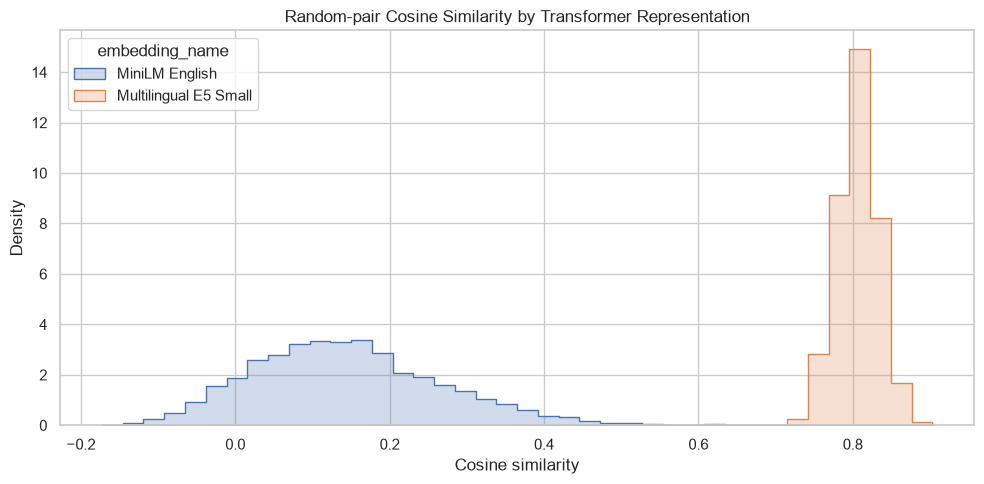


### Result interpretation — embedding geometry

- Mean vector norms remain approximately one, confirming consistent normalization before classification and cosine-neighbor analysis.
- **Multilingual E5 Small** has the higher random-pair cosine baseline (0.807). Absolute cosine levels are model-specific; neighbor ordering and downstream performance are more meaningful than comparing raw cosine values across encoders.
- Near-zero-variance dimensions are reported as a collapse check. Geometry diagnostics can identify malformed artifacts, but they are not substitutes for grouped validation.


In [9]:
# Sample deterministic non-self pairs rather than materializing every pairwise similarity.
rng = np.random.default_rng(RANDOM_STATE)
geometry_rows = []
pairwise_samples = []

for embedding_name, matrix in embedding_matrices.items():
    norms = np.linalg.norm(matrix, axis=1)
    left_positions = rng.integers(0, len(matrix), size=2_000)
    offsets = rng.integers(1, len(matrix), size=2_000)
    right_positions = (left_positions + offsets) % len(matrix)
    sampled_cosines = np.sum(
        matrix[left_positions] * matrix[right_positions],
        axis=1,
    )

    geometry_rows.append(
        {
            "embedding_name": embedding_name,
            "mean_norm": norms.mean(),
            "norm_std": norms.std(),
            "mean_random_pair_cosine": sampled_cosines.mean(),
            "random_pair_cosine_std": sampled_cosines.std(),
            "p05_random_pair_cosine": np.quantile(sampled_cosines, 0.05),
            "p95_random_pair_cosine": np.quantile(sampled_cosines, 0.95),
            "near_zero_variance_dimensions": int(
                (matrix.var(axis=0) < 1e-8).sum()
            ),
        }
    )
    pairwise_samples.append(
        pd.DataFrame(
            {
                "embedding_name": embedding_name,
                "cosine_similarity": sampled_cosines,
            }
        )
    )

# Compare compact geometry summaries and distributions across the two encoder spaces.
embedding_geometry = pd.DataFrame(geometry_rows)
pairwise_sample_frame = pd.concat(pairwise_samples, ignore_index=True)
display(embedding_geometry.round(4))

plt.figure(figsize=(10, 5))
sns.histplot(
    data=pairwise_sample_frame,
    x="cosine_similarity",
    hue="embedding_name",
    bins=40,
    element="step",
    stat="density",
    common_norm=False,
)
plt.title("Random-pair Cosine Similarity by Transformer Representation")
plt.xlabel("Cosine similarity")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "embedding_cosine_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

highest_baseline_cosine = embedding_geometry.sort_values(
    "mean_random_pair_cosine", ascending=False
).iloc[0]
display(
    Markdown(
        f"""
### Result interpretation — embedding geometry

- Mean vector norms remain approximately one, confirming consistent normalization before classification and cosine-neighbor analysis.
- **{highest_baseline_cosine['embedding_name']}** has the higher random-pair cosine baseline ({highest_baseline_cosine['mean_random_pair_cosine']:.3f}). Absolute cosine levels are model-specific; neighbor ordering and downstream performance are more meaningful than comparing raw cosine values across encoders.
- Near-zero-variance dimensions are reported as a collapse check. Geometry diagnostics can identify malformed artifacts, but they are not substitutes for grouped validation.
"""
    )
)

## 6. Frozen labels, partitions, and evaluation utilities

In [10]:
# Derive all partition masks once from the frozen manifest to avoid inconsistent filtering.
train_mask = analysis["split"].eq("train").to_numpy()
validation_mask = analysis["split"].eq("validation").to_numpy()
test_mask = analysis["split"].eq("test").to_numpy()
development_mask = analysis["split"].isin(["train", "validation"]).to_numpy()

y_train = label_matrix[train_mask]
y_validation = label_matrix[validation_mask]
y_test = label_matrix[test_mask]
y_development = label_matrix[development_mask]

# Work-group IDs keep alternate editions of the same work within a single CV fold.
train_groups = analysis.loc[train_mask, "work_group"].to_numpy()
development_groups = analysis.loc[development_mask, "work_group"].to_numpy()

# Use Macro F1 for selection and retain Micro F1 as an imbalance-sensitive secondary view.
macro_f1_scorer = make_scorer(f1_score, average="macro", zero_division=0)
micro_f1_scorer = make_scorer(f1_score, average="micro", zero_division=0)
scoring = {
    "macro_f1": macro_f1_scorer,
    "micro_f1": micro_f1_scorer,
}


# Normalize classifier interfaces into one score matrix for AP and threshold analysis.
def continuous_scores(estimator: Pipeline, features: np.ndarray) -> np.ndarray:
    if hasattr(estimator, "decision_function"):
        return np.asarray(estimator.decision_function(features))
    if hasattr(estimator, "predict_proba"):
        probabilities = np.asarray(estimator.predict_proba(features))
        return probabilities - 0.5
    raise TypeError("Estimator must expose decision_function or predict_proba.")


# Report complementary multilabel metrics so Macro F1 is not interpreted in isolation.
def multilabel_metrics(
    true_labels: np.ndarray,
    predicted_labels: np.ndarray,
    scores: np.ndarray | None = None,
) -> dict[str, float]:
    values = {
        "macro_f1": f1_score(
            true_labels, predicted_labels, average="macro", zero_division=0
        ),
        "micro_f1": f1_score(
            true_labels, predicted_labels, average="micro", zero_division=0
        ),
        "weighted_f1": f1_score(
            true_labels, predicted_labels, average="weighted", zero_division=0
        ),
        "subset_accuracy": accuracy_score(true_labels, predicted_labels),
        "hamming_loss": hamming_loss(true_labels, predicted_labels),
    }
    values["macro_average_precision"] = (
        average_precision_score(true_labels, scores, average="macro")
        if scores is not None
        else np.nan
    )
    return values


# Tune each label only from out-of-fold scores, breaking ties toward the default zero threshold.
def tune_per_label_thresholds(
    true_labels: np.ndarray,
    scores: np.ndarray,
    quantile_points: int = 81,
) -> np.ndarray:
    thresholds = np.zeros(scores.shape[1], dtype=np.float32)
    quantiles = np.linspace(0.01, 0.99, quantile_points)

    for label_index in range(scores.shape[1]):
        label_scores = scores[:, label_index]
        candidates = np.unique(
            np.concatenate(
                [
                    np.quantile(label_scores, quantiles),
                    np.asarray([0.0], dtype=float),
                ]
            )
        )
        candidate_results = [
            (
                f1_score(
                    true_labels[:, label_index],
                    label_scores >= threshold,
                    zero_division=0,
                ),
                -abs(float(threshold)),
                float(threshold),
            )
            for threshold in candidates
        ]
        thresholds[label_index] = max(candidate_results)[2]

    return thresholds


# Broadcast the learned label thresholds consistently across every evaluated book.
def predictions_from_thresholds(
    scores: np.ndarray,
    thresholds: np.ndarray,
) -> np.ndarray:
    return (scores >= thresholds.reshape(1, -1)).astype(np.int8)

## 7. Classifiers and bounded hyperparameter grids

In [11]:
# Keep scaling inside the pipeline so it is fitted independently within every CV fold.
def build_classifier_pipeline(model_name: str) -> Pipeline:
    if model_name == "Logistic Regression":
        classifier = OneVsRestClassifier(
            LogisticRegression(
                solver="liblinear",
                max_iter=5_000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )
        )
    elif model_name == "Linear SVM":
        classifier = OneVsRestClassifier(
            LinearSVC(
                dual="auto",
                tol=1e-3,
                max_iter=10_000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )
        )
    else:
        raise KeyError(f"Unknown classifier: {model_name}")

    return Pipeline(
        [
            ("scaler", StandardScaler()),
            ("classifier", classifier),
        ]
    )


# Bound regularization grids to test meaningful capacity changes without excessive search.
MODEL_NAMES = ["Logistic Regression", "Linear SVM"]
PARAMETER_GRIDS = {
    "Logistic Regression": {
        "classifier__estimator__C": [0.1, 1.0, 10.0],
    },
    "Linear SVM": {
        "classifier__estimator__C": [0.01, 0.05, 0.1, 1.0],
    },
}

# Make the complete experiment matrix visible before any validation results are produced.
experiment_design = pd.DataFrame(
    [
        {
            "embedding": config["embedding_name"],
            "classifier": model_name,
            "threshold_policies": "Default and training-OOF tuned",
            "selection_metric": "Validation Macro F1",
        }
        for config in MODEL_CONFIGS
        for model_name in MODEL_NAMES
    ]
)
display(experiment_design)

,embedding,classifier,threshold_policies,selection_metric
0,MiniLM English,Logistic Regression,Default and training-OOF tuned,Validation Macro F1
1,MiniLM English,Linear SVM,Default and training-OOF tuned,Validation Macro F1
2,Multilingual E5 Small,Logistic Regression,Default and training-OOF tuned,Validation Macro F1
3,Multilingual E5 Small,Linear SVM,Default and training-OOF tuned,Validation Macro F1


## 8. Grouped cross-validation, grid search, and training-OOF thresholds

Each encoder/classifier pair uses identical five-fold `GroupKFold` partitions. Grid search selects regularization by training cross-validation Macro F1.

The threshold ablation is also leakage-safe: thresholds are learned from out-of-fold training scores, then applied unchanged to validation. Validation selects one representation, classifier, and threshold policy. The test partition is not accessed in this section.

In [12]:
# Retain compact result rows plus the selected parameters and thresholds needed for refitting.
experiment_rows = []
best_parameters_by_experiment: dict[tuple[str, str], dict[str, object]] = {}
training_thresholds_by_experiment: dict[tuple[str, str], np.ndarray] = {}

# Evaluate every encoder/classifier pair on identical training rows and work-group folds.
for embedding_name, matrix in embedding_matrices.items():
    X_train_embedding = matrix[train_mask]
    X_validation_embedding = matrix[validation_mask]

    for model_name in MODEL_NAMES:
        experiment_key = (embedding_name, model_name)
        cv_strategy = GroupKFold(n_splits=CV_SPLITS)

        # Select regularization strictly through grouped training cross-validation.
        search = GridSearchCV(
            estimator=build_classifier_pipeline(model_name),
            param_grid=PARAMETER_GRIDS[model_name],
            scoring=scoring,
            refit="macro_f1",
            cv=cv_strategy,
            n_jobs=N_JOBS,
            return_train_score=False,
            error_score="raise",
        )
        search_started_at = perf_counter()
        search.fit(X_train_embedding, y_train, groups=train_groups)
        grid_search_seconds = perf_counter() - search_started_at

        best_estimator = search.best_estimator_
        # Apply the CV-selected estimator once to validation for controlled model selection.
        validation_scores = continuous_scores(
            best_estimator,
            X_validation_embedding,
        )
        default_validation_predictions = best_estimator.predict(
            X_validation_embedding
        )
        default_validation_metrics = multilabel_metrics(
            y_validation,
            default_validation_predictions,
            validation_scores,
        )

        # Rebuild training scores out of fold so threshold tuning never sees in-sample scores.
        oof_scores = cross_val_predict(
            clone(best_estimator),
            X_train_embedding,
            y_train,
            groups=train_groups,
            cv=GroupKFold(n_splits=CV_SPLITS),
            method="decision_function",
            n_jobs=N_JOBS,
        )
        tuned_thresholds = tune_per_label_thresholds(y_train, oof_scores)
        tuned_validation_predictions = predictions_from_thresholds(
            validation_scores,
            tuned_thresholds,
        )
        tuned_validation_metrics = multilabel_metrics(
            y_validation,
            tuned_validation_predictions,
            validation_scores,
        )
        oof_tuned_macro_f1 = f1_score(
            y_train,
            predictions_from_thresholds(oof_scores, tuned_thresholds),
            average="macro",
            zero_division=0,
        )

        best_index = search.best_index_
        best_parameters_by_experiment[experiment_key] = search.best_params_
        training_thresholds_by_experiment[experiment_key] = tuned_thresholds

        # Store default and tuned policies separately to isolate the threshold contribution.
        for threshold_policy, validation_metrics in [
            ("Default", default_validation_metrics),
            ("Training-OOF tuned", tuned_validation_metrics),
        ]:
            experiment_rows.append(
                {
                    "embedding": embedding_name,
                    "model": model_name,
                    "threshold_policy": threshold_policy,
                    "cv_macro_f1_mean": search.cv_results_[
                        "mean_test_macro_f1"
                    ][best_index],
                    "cv_macro_f1_std": search.cv_results_[
                        "std_test_macro_f1"
                    ][best_index],
                    "cv_micro_f1_mean": search.cv_results_[
                        "mean_test_micro_f1"
                    ][best_index],
                    "training_oof_tuned_macro_f1": oof_tuned_macro_f1,
                    "mean_cv_fit_seconds": search.cv_results_[
                        "mean_fit_time"
                    ][best_index],
                    "grid_search_seconds": grid_search_seconds,
                    "validation_macro_f1": validation_metrics["macro_f1"],
                    "validation_micro_f1": validation_metrics["micro_f1"],
                    "validation_macro_average_precision": validation_metrics[
                        "macro_average_precision"
                    ],
                    "validation_subset_accuracy": validation_metrics[
                        "subset_accuracy"
                    ],
                    "validation_hamming_loss": validation_metrics[
                        "hamming_loss"
                    ],
                    "best_parameters": json.dumps(
                        search.best_params_,
                        sort_keys=True,
                    ),
                }
            )

        print(
            f"{embedding_name} | {model_name}: "
            f"CV={search.best_score_:.3f}; "
            f"validation default={default_validation_metrics['macro_f1']:.3f}; "
            f"validation OOF-thresholded={tuned_validation_metrics['macro_f1']:.3f}; "
            f"search={grid_search_seconds:.1f}s"
        )

# Rank pipelines by the declared validation metric, using secondary evidence only for ties.
model_comparison = (
    pd.DataFrame(experiment_rows)
    .sort_values(
        [
            "validation_macro_f1",
            "cv_macro_f1_mean",
            "validation_macro_average_precision",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    model_comparison[
        [
            "embedding",
            "model",
            "threshold_policy",
            "cv_macro_f1_mean",
            "cv_macro_f1_std",
            "validation_macro_f1",
            "validation_micro_f1",
            "validation_macro_average_precision",
            "mean_cv_fit_seconds",
            "grid_search_seconds",
            "best_parameters",
        ]
    ].round(4)
)

MiniLM English | Logistic Regression: CV=0.540; validation default=0.559; validation OOF-thresholded=0.581; search=15.0s
MiniLM English | Linear SVM: CV=0.538; validation default=0.557; validation OOF-thresholded=0.576; search=9.3s
Multilingual E5 Small | Logistic Regression: CV=0.567; validation default=0.569; validation OOF-thresholded=0.576; search=7.2s
Multilingual E5 Small | Linear SVM: CV=0.559; validation default=0.566; validation OOF-thresholded=0.571; search=8.9s


,embedding,model,threshold_policy,cv_macro_f1_mean,cv_macro_f1_std,validation_macro_f1,validation_micro_f1,validation_macro_average_precision,mean_cv_fit_seconds,grid_search_seconds,best_parameters
0,MiniLM English,Logistic Regression,Training-OOF tuned,0.5398,0.0142,0.5805,0.6660,0.6212,3.8688,14.9850,"{""classifier__estimator__C"": 0.1}"
1,MiniLM English,Linear SVM,Training-OOF tuned,0.5381,0.0149,0.5763,0.6578,0.6190,2.4706,9.2883,"{""classifier__estimator__C"": 0.01}"
2,Multilingual E5 Small,Logistic Regression,Training-OOF tuned,0.5667,0.0097,0.5756,0.6699,0.6088,2.7526,7.2019,"{""classifier__estimator__C"": 0.1}"
3,Multilingual E5 Small,Linear SVM,Training-OOF tuned,0.5594,0.0097,0.5706,0.6677,0.6031,1.8202,8.9199,"{""classifier__estimator__C"": 0.01}"
4,Multilingual E5 Small,Logistic Regression,Default,0.5667,0.0097,0.5694,0.6430,0.6088,2.7526,7.2019,"{""classifier__estimator__C"": 0.1}"
5,Multilingual E5 Small,Linear SVM,Default,0.5594,0.0097,0.5657,0.6403,0.6031,1.8202,8.9199,"{""classifier__estimator__C"": 0.01}"
6,MiniLM English,Logistic Regression,Default,0.5398,0.0142,0.5589,0.6172,0.6212,3.8688,14.9850,"{""classifier__estimator__C"": 0.1}"
7,MiniLM English,Linear SVM,Default,0.5381,0.0149,0.5572,0.6158,0.6190,2.4706,9.2883,"{""classifier__estimator__C"": 0.01}"


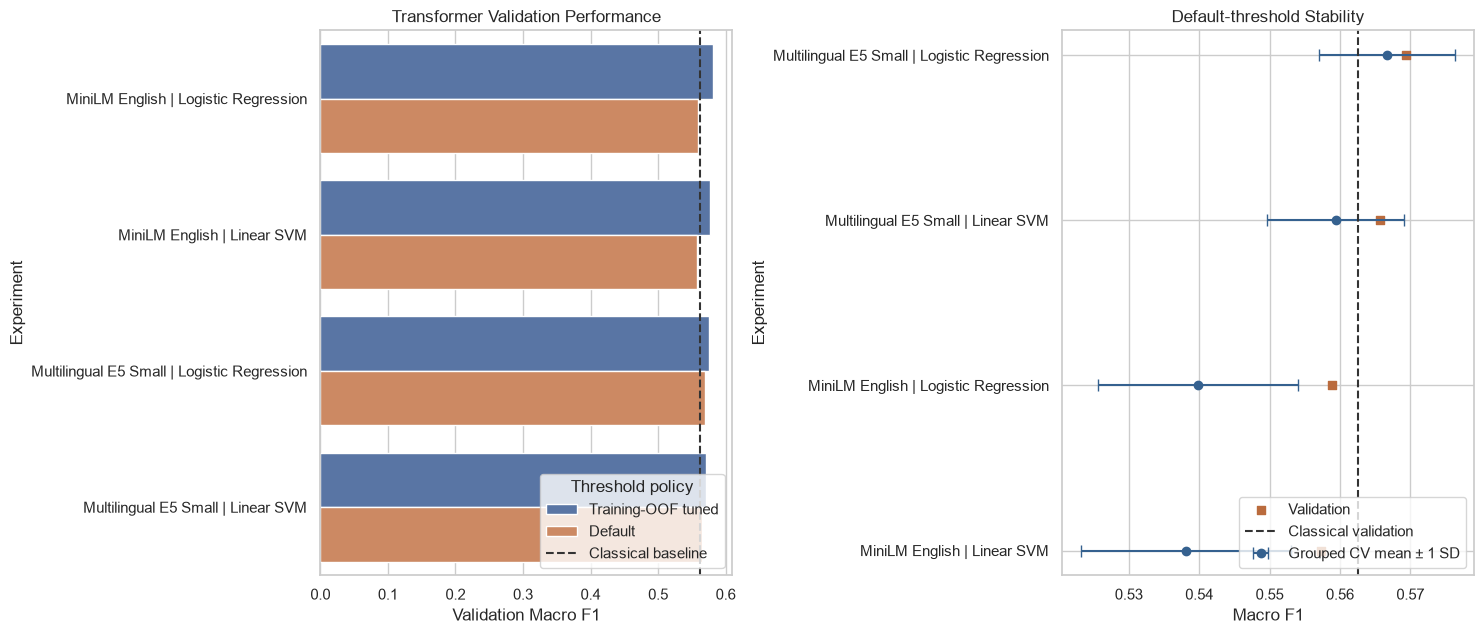


### Result interpretation — transformer validation comparison

- The selected validation configuration is **MiniLM English / Logistic Regression / Training-OOF tuned**, with Macro F1 0.5805.
- Relative to the frozen classical validation score (0.5626), the change is +0.0180: **a material improvement** under the predeclared +0.01 criterion.
- The best default-threshold result is 0.5694 (+0.0068 versus classical); the best training-OOF-thresholded result is 0.5805. The selected configuration's threshold policy changes its own score by +0.0217.
- The default-threshold comparison is the cleaner representation test because Notebook 04 used default thresholds. The tuned result is a separate pipeline ablation; its thresholds never use validation labels.
- Overlapping cross-validation variability should temper claims based on small score differences. Representation, classifier, threshold policy, and secondary metrics remain locked after this point.


In [13]:
# Contrast validation performance and grouped-CV stability without plotting redundant rows.
comparison_plot_data = model_comparison.copy()
comparison_plot_data["experiment"] = (
    comparison_plot_data["embedding"] + " | " + comparison_plot_data["model"]
)

default_results = comparison_plot_data.loc[
    comparison_plot_data["threshold_policy"] == "Default"
].sort_values("cv_macro_f1_mean")
y_positions = np.arange(len(default_results))

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

sns.barplot(
    data=comparison_plot_data,
    y="experiment",
    x="validation_macro_f1",
    hue="threshold_policy",
    orient="h",
    ax=axes[0],
)
axes[0].axvline(
    classical_validation_macro_f1,
    color="#333333",
    linestyle="--",
    linewidth=1.5,
    label="Classical baseline",
)
axes[0].set_title("Transformer Validation Performance")
axes[0].set_xlabel("Validation Macro F1")
axes[0].set_ylabel("Experiment")
axes[0].legend(title="Threshold policy", loc="lower right")

axes[1].errorbar(
    default_results["cv_macro_f1_mean"],
    y_positions,
    xerr=default_results["cv_macro_f1_std"],
    fmt="o",
    color="#35618f",
    capsize=4,
    label="Grouped CV mean ± 1 SD",
)
axes[1].scatter(
    default_results["validation_macro_f1"],
    y_positions,
    color="#ba6b3d",
    marker="s",
    label="Validation",
)
axes[1].axvline(
    classical_validation_macro_f1,
    color="#333333",
    linestyle="--",
    linewidth=1.5,
    label="Classical validation",
)
axes[1].set_yticks(y_positions)
axes[1].set_yticklabels(default_results["experiment"])
axes[1].set_title("Default-threshold Stability")
axes[1].set_xlabel("Macro F1")
axes[1].set_ylabel("Experiment")
axes[1].legend(loc="lower right")

plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "transformer_model_comparison.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

# Lock the highest-ranked validation pipeline before the held-out test is accessed.
selected_validation_row = model_comparison.iloc[0]
validation_delta = (
    selected_validation_row["validation_macro_f1"]
    - classical_validation_macro_f1
)
if validation_delta >= MATERIAL_MACRO_F1_GAIN:
    validation_assessment = "a material improvement"
elif validation_delta > 0:
    validation_assessment = "a positive but sub-threshold improvement"
else:
    validation_assessment = "no improvement"

# Separate the encoder comparison from gains attributable to per-label threshold tuning.
best_default = (
    model_comparison.loc[model_comparison["threshold_policy"] == "Default"]
    .sort_values("validation_macro_f1", ascending=False)
    .iloc[0]
)
best_tuned = (
    model_comparison.loc[
        model_comparison["threshold_policy"] == "Training-OOF tuned"
    ]
    .sort_values("validation_macro_f1", ascending=False)
    .iloc[0]
)
best_default_delta = (
    best_default["validation_macro_f1"] - classical_validation_macro_f1
)
selected_default_row = model_comparison.loc[
    (model_comparison["embedding"] == selected_validation_row["embedding"])
    & (model_comparison["model"] == selected_validation_row["model"])
    & (model_comparison["threshold_policy"] == "Default")
].iloc[0]
selected_threshold_lift = (
    selected_validation_row["validation_macro_f1"]
    - selected_default_row["validation_macro_f1"]
)

display(
    Markdown(
        f"""
### Result interpretation — transformer validation comparison

- The selected validation configuration is **{selected_validation_row['embedding']} / {selected_validation_row['model']} / {selected_validation_row['threshold_policy']}**, with Macro F1 {selected_validation_row['validation_macro_f1']:.4f}.
- Relative to the frozen classical validation score ({classical_validation_macro_f1:.4f}), the change is {validation_delta:+.4f}: **{validation_assessment}** under the predeclared +{MATERIAL_MACRO_F1_GAIN:.2f} criterion.
- The best default-threshold result is {best_default['validation_macro_f1']:.4f} ({best_default_delta:+.4f} versus classical); the best training-OOF-thresholded result is {best_tuned['validation_macro_f1']:.4f}. The selected configuration's threshold policy changes its own score by {selected_threshold_lift:+.4f}.
- The default-threshold comparison is the cleaner representation test because Notebook 04 used default thresholds. The tuned result is a separate pipeline ablation; its thresholds never use validation labels.
- Overlapping cross-validation variability should temper claims based on small score differences. Representation, classifier, threshold policy, and secondary metrics remain locked after this point.
"""
    )
)

## 9. Lock one transformer pipeline and evaluate the test partition once

In [14]:
# Materialize the locked representation, classifier, and threshold policy exactly once.
selected_row = model_comparison.iloc[0]
selected_embedding = selected_row["embedding"]
selected_model = selected_row["model"]
selected_threshold_policy = selected_row["threshold_policy"]
selected_experiment_key = (selected_embedding, selected_model)

# Combine train and validation only after selection; the test features remain untouched.
selected_matrix = embedding_matrices[selected_embedding]
X_development_embedding = selected_matrix[development_mask]
X_test_embedding = selected_matrix[test_mask]

# Recreate the selected pipeline with its previously chosen hyperparameters.
final_pipeline = build_classifier_pipeline(selected_model)
final_pipeline.set_params(
    **best_parameters_by_experiment[selected_experiment_key]
)

# If selected, relearn thresholds from development out-of-fold scores before final fitting.
threshold_started_at = perf_counter()
if selected_threshold_policy == "Training-OOF tuned":
    development_oof_scores = cross_val_predict(
        clone(final_pipeline),
        X_development_embedding,
        y_development,
        groups=development_groups,
        cv=GroupKFold(n_splits=CV_SPLITS),
        method="decision_function",
        n_jobs=N_JOBS,
    )
    final_thresholds = tune_per_label_thresholds(
        y_development,
        development_oof_scores,
    )
else:
    final_thresholds = np.zeros(len(TARGET_GENRES), dtype=np.float32)
threshold_tuning_seconds = perf_counter() - threshold_started_at

final_fit_started_at = perf_counter()
final_pipeline.fit(X_development_embedding, y_development)
final_fit_seconds = perf_counter() - final_fit_started_at

# This is the notebook's single model access to the held-out test partition.
final_test_scores = continuous_scores(final_pipeline, X_test_embedding)
final_test_predictions = predictions_from_thresholds(
    final_test_scores,
    final_thresholds,
)
final_test_metric_values = multilabel_metrics(
    y_test,
    final_test_predictions,
    final_test_scores,
)

# Preserve one compact record of the locked test metrics and final training costs.
final_test_metrics = pd.DataFrame(
    [
        {
            "embedding": selected_embedding,
            "model": selected_model,
            "threshold_policy": selected_threshold_policy,
            "threshold_tuning_seconds": threshold_tuning_seconds,
            "final_fit_seconds": final_fit_seconds,
            **final_test_metric_values,
        }
    ]
)
selected_threshold_table = pd.DataFrame(
    {
        "genre": TARGET_GENRES,
        "decision_threshold": final_thresholds,
    }
)

print(f"Selected embedding: {selected_embedding}")
print(f"Selected classifier: {selected_model}")
print(f"Selected threshold policy: {selected_threshold_policy}")
print(
    f"Development threshold tuning: {threshold_tuning_seconds:.1f}s; "
    f"final fit: {final_fit_seconds:.1f}s"
)
display(final_test_metrics.round(4))
display(selected_threshold_table.round(4))

# Compare the locked outcome with the frozen Notebook 04 reference without reselection.
test_delta = final_test_metric_values["macro_f1"] - classical_test_macro_f1
exact_matches = int(
    np.all(y_test == final_test_predictions, axis=1).sum()
)
display(
    Markdown(
        f"""
### Result interpretation — locked final test

- The single locked transformer pipeline achieves test Macro F1 **{final_test_metric_values['macro_f1']:.4f}**, a change of {test_delta:+.4f} from the frozen classical test score ({classical_test_macro_f1:.4f}).
- Micro F1 is {final_test_metric_values['micro_f1']:.4f}, weighted F1 is {final_test_metric_values['weighted_f1']:.4f}, and macro average precision is {final_test_metric_values['macro_average_precision']:.4f}. Differences between these metrics indicate how label imbalance and ranking quality affect the result.
- Exact label vectors are correct for {exact_matches} of {len(y_test)} books ({final_test_metric_values['subset_accuracy']:.1%}). Hamming loss {final_test_metric_values['hamming_loss']:.4f} corresponds to approximately {10 * final_test_metric_values['hamming_loss']:.2f} incorrect label decisions per book across ten targets.
- This test result is now frozen. All subsequent cells analyze stored predictions and scores; they do not refit, reselect, or reevaluate alternative models on test.
"""
    )
)

Selected embedding: MiniLM English
Selected classifier: Logistic Regression
Selected threshold policy: Training-OOF tuned
Development threshold tuning: 2.5s; final fit: 1.9s


,embedding,model,threshold_policy,threshold_tuning_seconds,final_fit_seconds,macro_f1,micro_f1,weighted_f1,subset_accuracy,hamming_loss,macro_average_precision
0,MiniLM English,Logistic Regression,Training-OOF tuned,2.5377,1.8538,0.5553,0.6498,0.6506,0.1122,0.216,0.6003


,genre,decision_threshold
0,fiction,-1.8693
1,"history, historical fiction, biography",-0.1751
2,romance,-0.3051
3,non-fiction,0.8438
4,"fantasy, paranormal",-0.3098
5,"mystery, thriller, crime",-0.0975
6,young-adult,0.3655
7,children,1.4542
8,"comics, graphic",0.0000
9,poetry,2.6587



### Result interpretation — locked final test

- The single locked transformer pipeline achieves test Macro F1 **0.5553**, a change of -0.0128 from the frozen classical test score (0.5681).
- Micro F1 is 0.6498, weighted F1 is 0.6506, and macro average precision is 0.6003. Differences between these metrics indicate how label imbalance and ranking quality affect the result.
- Exact label vectors are correct for 59 of 526 books (11.2%). Hamming loss 0.2160 corresponds to approximately 2.16 incorrect label decisions per book across ten targets.
- This test result is now frozen. All subsequent cells analyze stored predictions and scores; they do not refit, reselect, or reevaluate alternative models on test.


## 10. Per-genre performance and error slices

,genre,support,precision,recall,f1,average_precision,classical_f1,f1_change_vs_classical
0,fiction,347,0.703,0.954,0.809,0.847,0.834,-0.025
3,non-fiction,155,0.739,0.677,0.707,0.808,0.767,-0.060
2,romance,177,0.618,0.797,0.696,0.800,0.694,0.003
1,"history, historical fiction, biography",198,0.624,0.773,0.691,0.727,0.659,0.032
4,"fantasy, paranormal",150,0.541,0.747,0.627,0.671,0.678,-0.051
5,"mystery, thriller, crime",148,0.479,0.696,0.567,0.622,0.604,-0.036
7,children,66,0.527,0.439,0.479,0.470,0.470,0.010
6,young-adult,106,0.385,0.491,0.432,0.413,0.487,-0.055
8,"comics, graphic",49,0.207,0.469,0.288,0.315,0.257,0.030
9,poetry,30,0.556,0.167,0.256,0.330,0.233,0.024


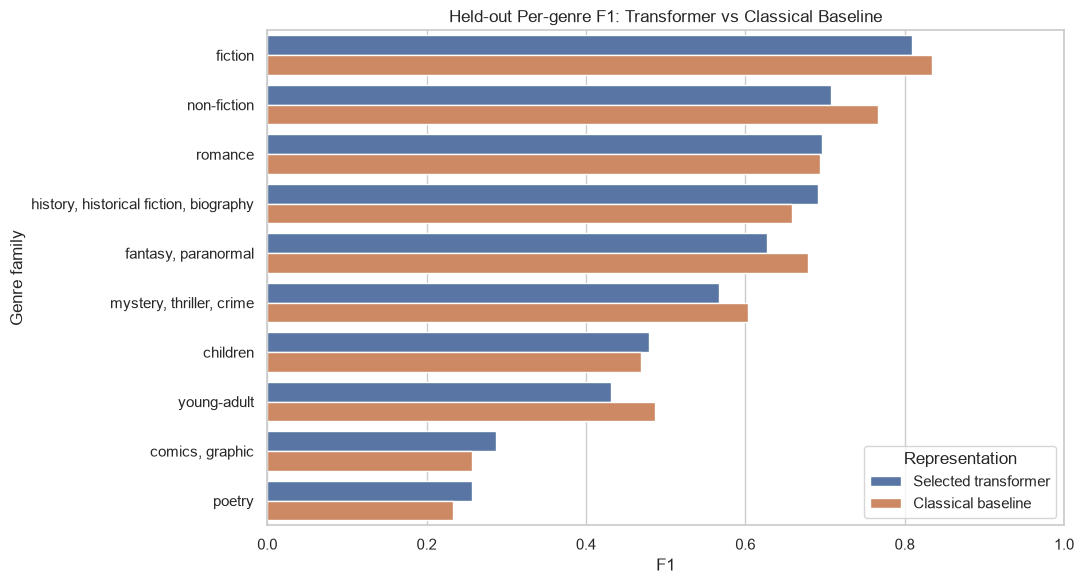

In [15]:
# Compute label-level metrics from the same locked predictions used for aggregate scoring.
per_genre_precision, per_genre_recall, per_genre_f1, per_genre_support = (
    precision_recall_fscore_support(
        y_test,
        final_test_predictions,
        average=None,
        zero_division=0,
    )
)
per_genre_average_precision = average_precision_score(
    y_test,
    final_test_scores,
    average=None,
)

# Join Notebook 04 per-genre F1 values to expose gains and regressions label by label.
per_genre_metrics = pd.DataFrame(
    {
        "genre": TARGET_GENRES,
        "support": per_genre_support.astype(int),
        "precision": per_genre_precision,
        "recall": per_genre_recall,
        "f1": per_genre_f1,
        "average_precision": per_genre_average_precision,
    }
).merge(
    classical_per_genre[["genre", "f1"]].rename(
        columns={"f1": "classical_f1"}
    ),
    on="genre",
    how="left",
    validate="one_to_one",
)
per_genre_metrics["f1_change_vs_classical"] = (
    per_genre_metrics["f1"] - per_genre_metrics["classical_f1"]
)
per_genre_metrics = per_genre_metrics.sort_values("f1", ascending=False)
display(per_genre_metrics.round(3))

per_genre_plot = per_genre_metrics[
    ["genre", "f1", "classical_f1"]
].melt(
    id_vars="genre",
    var_name="representation",
    value_name="f1_score",
)
per_genre_plot["representation"] = per_genre_plot["representation"].map(
    {
        "f1": "Selected transformer",
        "classical_f1": "Classical baseline",
    }
)

# Paired horizontal bars keep all ten genre labels readable on a shared F1 scale.
plt.figure(figsize=(11, 6))
sns.barplot(
    data=per_genre_plot,
    y="genre",
    x="f1_score",
    hue="representation",
    orient="h",
)
plt.title("Held-out Per-genre F1: Transformer vs Classical Baseline")
plt.xlabel("F1")
plt.ylabel("Genre family")
plt.xlim(0, 1)
plt.legend(title="Representation", loc="lower right")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "per_genre_transformer_vs_classical.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

,slice_dimension,slice_value,books,mean_true_labels,macro_f1,micro_f1,subset_accuracy,hamming_loss
0,language_group,English,243,2.7695,0.5835,0.6812,0.1111,0.1988
1,language_group,Non-English,96,2.8125,0.4072,0.5584,0.0312,0.2833
2,language_group,Unknown,187,2.5829,0.5656,0.6577,0.1551,0.2037
3,description_length_band,20–75,104,2.6635,0.4988,0.5837,0.1058,0.2510
4,description_length_band,76–150,225,2.7689,0.5783,0.6652,0.1022,0.2098
5,description_length_band,151–250,147,2.7551,0.5134,0.6616,0.1156,0.2109
6,description_length_band,251+,50,2.4200,0.5811,0.6804,0.1600,0.1860
7,label_cardinality_band,2,155,2.0000,0.4829,0.6286,0.1548,0.1929
8,label_cardinality_band,3,143,3.0000,0.5509,0.6709,0.0909,0.2161
9,label_cardinality_band,4+,129,4.5581,0.6163,0.7289,0.1318,0.2318


,book_id,title,language_group,true_genres,predicted_genres,label_error_count
437,14288407,Das Glück trägt Cowboystiefel,Non-English,"fiction | history, historical fiction, biography | romance | non-fiction","fiction | fantasy, paranormal | mystery, thriller, crime | young-adult | comics, graphic",7
65,12152955,Kenraalin Testamentti,Non-English,"history, historical fiction, biography | non-fiction","fiction | romance | fantasy, paranormal | children | comics, graphic",7
228,1115628,Die Möwe Jonathan,Non-English,"fiction | non-fiction | fantasy, paranormal | young-adult | children | poetry","fiction | history, historical fiction, biography | romance | children",6
196,26124639,Doctor Who: The Time Lord Letters,English,"fiction | romance | non-fiction | fantasy, paranormal | mystery, thriller, crime","fiction | history, historical fiction, biography | fantasy, paranormal | young-adult |...",6
156,32183341,Ni'ihau: The Last Hawaiian Island,English,non-fiction,"fiction | history, historical fiction, biography | fantasy, paranormal | children | co...",6
50,350762,Tao Te Ching,English,"fiction | history, historical fiction, biography | non-fiction | poetry","fantasy, paranormal | comics, graphic",6
496,31932889,"Tuesday's Promise: One Veteran, One Dog, and Their Bold Quest to Change Lives",English,"history, historical fiction, biography | non-fiction","fiction | mystery, thriller, crime | young-adult | children",6
97,25535550,文豪ストレイドッグス 太宰治と黒の時代 [Bungō Stray Dogs - Dazai Osamu to kuro no jidai],Non-English,"mystery, thriller, crime","fiction | romance | fantasy, paranormal | young-adult | comics, graphic",6
113,21965587,Big Red Kangaroo,Unknown,non-fiction | children,"fiction | fantasy, paranormal | comics, graphic",5
515,12247405,Blue Thread,Unknown,"fiction | history, historical fiction, biography | romance | fantasy, paranormal | you...","history, historical fiction, biography | non-fiction",5


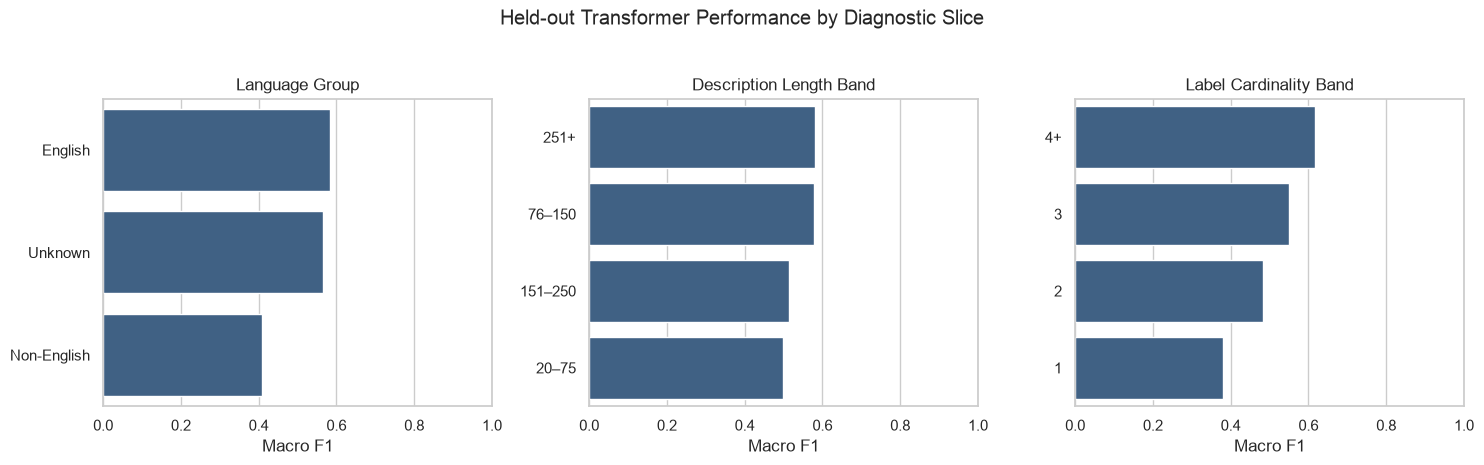


### Result interpretation — genre performance and failure structure

- The strongest genre is **fiction** at F1 0.809; the weakest is **poetry** at F1 0.256 with support 30.
- The largest per-genre gain over the classical baseline is **history, historical fiction, biography** (+0.032); the largest decline is **non-fiction** (-0.060). Aggregate improvement should not hide rare-label regressions.
- Among slices with at least 20 test books, the lowest Macro F1 occurs for **label_cardinality_band = 1** (0.380, n=99).
- Slice results are diagnostic, not causal. Language metadata, description length, label cardinality, weak-label ambiguity, and support can interact; the exported error table is the basis for follow-on review.


In [16]:
# Convert binary label rows into readable genre lists for exported error inspection.
def active_label_names(row: np.ndarray) -> list[str]:
    return [
        genre for genre, active in zip(TARGET_GENRES, row) if active
    ]


# Build one diagnostic row per test book while retaining identifiers and slice attributes.
test_error_analysis = analysis.loc[
    test_mask,
    [
        "book_id",
        "work_id",
        "title",
        "language_code_clean",
        "language_group",
        "text_word_count",
        "clean_description",
    ],
].reset_index(drop=True)

# Record true, predicted, missed, and extra labels so failures remain directly inspectable.
test_error_analysis["true_genres"] = [
    " | ".join(active_label_names(row)) for row in y_test
]
test_error_analysis["predicted_genres"] = [
    " | ".join(active_label_names(row))
    for row in final_test_predictions
]
test_error_analysis["missed_genres"] = [
    " | ".join(
        genre
        for genre, true_value, predicted_value in zip(
            TARGET_GENRES, true_row, predicted_row
        )
        if true_value and not predicted_value
    )
    for true_row, predicted_row in zip(y_test, final_test_predictions)
]
test_error_analysis["extra_genres"] = [
    " | ".join(
        genre
        for genre, true_value, predicted_value in zip(
            TARGET_GENRES, true_row, predicted_row
        )
        if predicted_value and not true_value
    )
    for true_row, predicted_row in zip(y_test, final_test_predictions)
]
test_error_analysis["label_error_count"] = np.abs(
    y_test - final_test_predictions
).sum(axis=1)
test_error_analysis["true_label_count"] = y_test.sum(axis=1)
test_error_analysis["predicted_label_count"] = final_test_predictions.sum(
    axis=1
)

# Use predeclared coarse bands to avoid interpreting unstable one-off numeric slices.
test_error_analysis["description_length_band"] = pd.cut(
    test_error_analysis["text_word_count"],
    bins=[0, 75, 150, 250, np.inf],
    labels=["20–75", "76–150", "151–250", "251+"],
    include_lowest=True,
)
test_error_analysis["label_cardinality_band"] = pd.cut(
    test_error_analysis["true_label_count"],
    bins=[0, 1, 2, 3, np.inf],
    labels=["1", "2", "3", "4+"],
    include_lowest=True,
)

# Skip undersized slices and compute every retained slice with the same metric function.
slice_rows = []
for slice_dimension in [
    "language_group",
    "description_length_band",
    "label_cardinality_band",
]:
    for slice_value in test_error_analysis[slice_dimension].dropna().unique():
        slice_mask = (
            test_error_analysis[slice_dimension].astype(str)
            == str(slice_value)
        ).to_numpy()
        slice_books = int(slice_mask.sum())
        if slice_books < MIN_SLICE_BOOKS:
            continue

        slice_metrics = multilabel_metrics(
            y_test[slice_mask],
            final_test_predictions[slice_mask],
        )
        slice_rows.append(
            {
                "slice_dimension": slice_dimension,
                "slice_value": str(slice_value),
                "books": slice_books,
                "mean_true_labels": y_test[slice_mask].sum(axis=1).mean(),
                "macro_f1": slice_metrics["macro_f1"],
                "micro_f1": slice_metrics["micro_f1"],
                "subset_accuracy": slice_metrics["subset_accuracy"],
                "hamming_loss": slice_metrics["hamming_loss"],
            }
        )

error_slice_metrics = pd.DataFrame(slice_rows)
display(error_slice_metrics.round(4))

display(
    test_error_analysis.sort_values(
        ["label_error_count", "title"],
        ascending=[False, True],
    )[
        [
            "book_id",
            "title",
            "language_group",
            "true_genres",
            "predicted_genres",
            "label_error_count",
        ]
    ].head(10)
)

# Give each slice dimension its own panel so category scales remain legible.
slice_dimensions = error_slice_metrics["slice_dimension"].unique().tolist()
fig, axes = plt.subplots(
    1,
    len(slice_dimensions),
    figsize=(5 * len(slice_dimensions), 4.5),
    squeeze=False,
)
for axis, slice_dimension in zip(axes[0], slice_dimensions):
    plot_data = error_slice_metrics.loc[
        error_slice_metrics["slice_dimension"] == slice_dimension
    ].sort_values("macro_f1", ascending=False)
    sns.barplot(
        data=plot_data,
        x="macro_f1",
        y="slice_value",
        color="#35618f",
        ax=axis,
    )
    axis.set_title(slice_dimension.replace("_", " ").title())
    axis.set_xlabel("Macro F1")
    axis.set_ylabel("")
    axis.set_xlim(0, 1)
plt.suptitle("Held-out Transformer Performance by Diagnostic Slice", y=1.03)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "transformer_error_slices.png", dpi=160, bbox_inches="tight")
plt.show()

# Surface the strongest, weakest, and largest-change cases for the narrative checkpoint.
strongest_genre = per_genre_metrics.iloc[0]
weakest_genre = per_genre_metrics.iloc[-1]
largest_gain = per_genre_metrics.sort_values(
    "f1_change_vs_classical", ascending=False
).iloc[0]
largest_decline = per_genre_metrics.sort_values(
    "f1_change_vs_classical", ascending=True
).iloc[0]
weakest_slice = error_slice_metrics.sort_values("macro_f1").iloc[0]

display(
    Markdown(
        f"""
### Result interpretation — genre performance and failure structure

- The strongest genre is **{strongest_genre['genre']}** at F1 {strongest_genre['f1']:.3f}; the weakest is **{weakest_genre['genre']}** at F1 {weakest_genre['f1']:.3f} with support {int(weakest_genre['support'])}.
- The largest per-genre gain over the classical baseline is **{largest_gain['genre']}** ({largest_gain['f1_change_vs_classical']:+.3f}); the largest decline is **{largest_decline['genre']}** ({largest_decline['f1_change_vs_classical']:+.3f}). Aggregate improvement should not hide rare-label regressions.
- Among slices with at least {MIN_SLICE_BOOKS} test books, the lowest Macro F1 occurs for **{weakest_slice['slice_dimension']} = {weakest_slice['slice_value']}** ({weakest_slice['macro_f1']:.3f}, n={int(weakest_slice['books'])}).
- Slice results are diagnostic, not causal. Language metadata, description length, label cardinality, weak-label ambiguity, and support can interact; the exported error table is the basis for follow-on review.
"""
    )
)

## 11. Semantic-neighbor evaluation against LSA

To preserve the locked test boundary, this secondary retrieval proxy uses training books as candidates and validation books as queries. It compares all representations without consulting test labels or changing the selected classifier.

,representation,queries,neighbors_per_query,mean_neighbor_jaccard,shared_label_rate,mean_query_label_recall_at_k,mean_cosine_similarity
1,MiniLM English,525,5,0.4287,0.8636,0.9185,0.5004
0,LSA (100 dimensions),525,5,0.4141,0.8408,0.9031,0.6603
2,Multilingual E5 Small,525,5,0.4138,0.8408,0.9140,0.8715


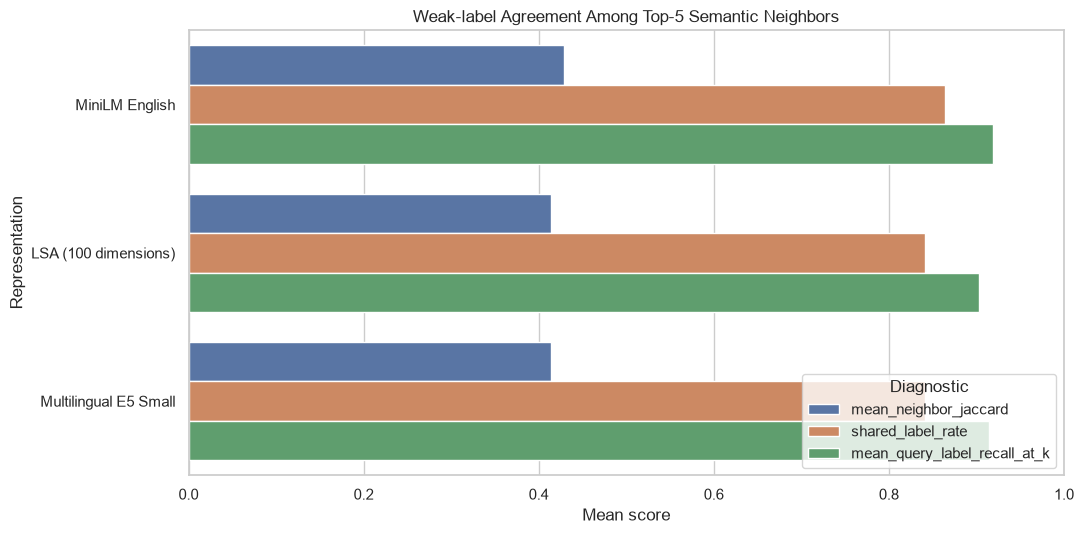

In [17]:
# Align Notebook 04 LSA rows to the frozen cohort before any neighbor comparison.
lsa_columns = [
    column for column in lsa_features.columns if column.startswith("lsa_")
]
lsa_aligned = (
    lsa_features.set_index("book_id")
    .loc[analysis["book_id"], lsa_columns]
    .to_numpy(dtype=np.float32)
)
# Unit-normalize LSA so every representation uses the same cosine-distance convention.
lsa_aligned = normalize(lsa_aligned, norm="l2").astype(np.float32)

neighbor_representations = {
    "LSA (100 dimensions)": lsa_aligned,
    **embedding_matrices,
}

# Use training candidates and validation queries to keep all alternative views off test labels.
neighbor_corpus_positions = np.flatnonzero(train_mask)
neighbor_query_positions = np.flatnonzero(validation_mask)


# Apply one fixed retrieval protocol to each representation for a controlled comparison.
def evaluate_neighbor_representation(
    representation_name: str,
    matrix: np.ndarray,
) -> tuple[dict[str, float], np.ndarray, np.ndarray]:
    neighbor_model = NearestNeighbors(
        n_neighbors=NEIGHBOR_K,
        metric="cosine",
        algorithm="brute",
        n_jobs=N_JOBS,
    )
    neighbor_model.fit(matrix[neighbor_corpus_positions])
    distances, local_neighbor_positions = neighbor_model.kneighbors(
        matrix[neighbor_query_positions]
    )
    global_neighbor_positions = neighbor_corpus_positions[
        local_neighbor_positions
    ]
    similarities = 1.0 - distances

    query_labels = label_matrix[neighbor_query_positions]
    neighbor_labels = label_matrix[global_neighbor_positions]

    # Weak-label overlap is a proxy for relevance, not a substitute for human judgments.
    intersection = (
        neighbor_labels
        & query_labels[:, None, :]
    ).sum(axis=2)
    union = (
        neighbor_labels
        | query_labels[:, None, :]
    ).sum(axis=2)
    jaccard = np.divide(
        intersection,
        union,
        out=np.zeros_like(intersection, dtype=float),
        where=union > 0,
    )
    shared_label = intersection > 0
    covered_query_labels = neighbor_labels.max(axis=1) & query_labels
    label_recall_at_k = np.divide(
        covered_query_labels.sum(axis=1),
        query_labels.sum(axis=1),
        out=np.zeros(len(query_labels), dtype=float),
        where=query_labels.sum(axis=1) > 0,
    )

    metrics = {
        "representation": representation_name,
        "queries": len(neighbor_query_positions),
        "neighbors_per_query": NEIGHBOR_K,
        "mean_neighbor_jaccard": float(jaccard.mean()),
        "shared_label_rate": float(shared_label.mean()),
        "mean_query_label_recall_at_k": float(label_recall_at_k.mean()),
        "mean_cosine_similarity": float(similarities.mean()),
    }
    return metrics, global_neighbor_positions, similarities


# Retain aggregate metrics and neighbor identities for later quantitative and qualitative views.
neighbor_metric_rows = []
neighbor_details = {}

for representation_name, matrix in neighbor_representations.items():
    metrics, neighbor_positions, similarities = (
        evaluate_neighbor_representation(representation_name, matrix)
    )
    neighbor_metric_rows.append(metrics)
    neighbor_details[representation_name] = {
        "positions": neighbor_positions,
        "similarities": similarities,
    }

neighbor_metrics = pd.DataFrame(neighbor_metric_rows).sort_values(
    "mean_neighbor_jaccard",
    ascending=False,
)
display(neighbor_metrics.round(4))

neighbor_plot = neighbor_metrics.melt(
    id_vars="representation",
    value_vars=[
        "mean_neighbor_jaccard",
        "shared_label_rate",
        "mean_query_label_recall_at_k",
    ],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(11, 5.5))
sns.barplot(
    data=neighbor_plot,
    y="representation",
    x="score",
    hue="metric",
    orient="h",
)
plt.title(f"Weak-label Agreement Among Top-{NEIGHBOR_K} Semantic Neighbors")
plt.xlabel("Mean score")
plt.ylabel("Representation")
plt.xlim(0, 1)
plt.legend(title="Diagnostic", loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "semantic_neighbor_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

In [18]:
# Fix anchor genres before inspection to prevent choosing only favorable neighbor examples.
ANCHOR_GENRES = [
    "fiction",
    "non-fiction",
    "romance",
    "fantasy, paranormal",
    "poetry",
]

selected_neighbor_detail = neighbor_details[selected_embedding]
query_row_by_global_position = {
    global_position: query_row
    for query_row, global_position in enumerate(neighbor_query_positions)
}
# Select the first eligible validation book deterministically and avoid duplicate anchors.
anchor_positions = []
used_positions = set()

for genre in ANCHOR_GENRES:
    genre_index = TARGET_GENRES.index(genre)
    candidates = [
        position
        for position in neighbor_query_positions
        if label_matrix[position, genre_index] == 1
        and position not in used_positions
    ]
    candidates = sorted(
        candidates,
        key=lambda position: str(analysis.iloc[position]["book_id"]),
    )
    if candidates:
        selected_position = candidates[0]
        anchor_positions.append((genre, selected_position))
        used_positions.add(selected_position)

# Materialize a small readable table linking each anchor to its ranked training neighbors.
neighbor_example_rows = []
for anchor_genre, query_position in anchor_positions:
    query_row = query_row_by_global_position[query_position]
    neighbor_positions = selected_neighbor_detail["positions"][query_row]
    similarities = selected_neighbor_detail["similarities"][query_row]

    for rank, (neighbor_position, similarity) in enumerate(
        zip(neighbor_positions, similarities),
        start=1,
    ):
        neighbor_example_rows.append(
            {
                "anchor_genre": anchor_genre,
                "query_title": analysis.iloc[query_position]["title"],
                "query_genres": " | ".join(
                    active_label_names(label_matrix[query_position])
                ),
                "neighbor_rank": rank,
                "neighbor_title": analysis.iloc[neighbor_position]["title"],
                "neighbor_genres": " | ".join(
                    active_label_names(label_matrix[neighbor_position])
                ),
                "cosine_similarity": similarity,
            }
        )

neighbor_examples = pd.DataFrame(neighbor_example_rows)
display(neighbor_examples.round({"cosine_similarity": 4}))

# Quantify the selected transformer's neighbor change against the frozen LSA reference.
selected_neighbor_row = neighbor_metrics.loc[
    neighbor_metrics["representation"] == selected_embedding
].iloc[0]
lsa_neighbor_row = neighbor_metrics.loc[
    neighbor_metrics["representation"] == "LSA (100 dimensions)"
].iloc[0]
neighbor_jaccard_delta = (
    selected_neighbor_row["mean_neighbor_jaccard"]
    - lsa_neighbor_row["mean_neighbor_jaccard"]
)

display(
    Markdown(
        f"""
### Result interpretation — semantic neighbors

- The selected transformer reaches mean top-{NEIGHBOR_K} weak-label Jaccard {selected_neighbor_row['mean_neighbor_jaccard']:.4f}, a change of {neighbor_jaccard_delta:+.4f} from LSA.
- Its shared-label rate is {selected_neighbor_row['shared_label_rate']:.1%}, and the union of its top-{NEIGHBOR_K} neighbors recovers {selected_neighbor_row['mean_query_label_recall_at_k']:.1%} of each query book's weak labels on average.
- These metrics use noisy genre overlap as a proxy for semantic relevance. The fixed anchor examples provide necessary qualitative context, but a later retrieval notebook should add blinded human judgments before making product-level search claims.
"""
    )
)

,anchor_genre,query_title,query_genres,neighbor_rank,neighbor_title,neighbor_genres,cosine_similarity
0,fiction,Midnight Nation,"fiction | fantasy, paranormal | comics, graphic",1,The Stories: Five Years of Original Fiction on Tor.com,"fiction | history, historical fiction, biography | fantasy, paranormal",0.4755
1,fiction,Midnight Nation,"fiction | fantasy, paranormal | comics, graphic",2,"Shards of Hope (Psy-Changeling, #14)","fiction | romance | fantasy, paranormal | mystery, thriller, crime",0.4615
2,fiction,Midnight Nation,"fiction | fantasy, paranormal | comics, graphic",3,Dark Fragments,"fiction | mystery, thriller, crime",0.4495
3,fiction,Midnight Nation,"fiction | fantasy, paranormal | comics, graphic",4,Country of Unknown Origin,fiction,0.4474
4,fiction,Midnight Nation,"fiction | fantasy, paranormal | comics, graphic",5,Saving Alice,"fiction | fantasy, paranormal",0.4349
...,...,...,...,...,...,...,...
20,poetry,Mule,poetry,1,The Cracks Between What We are and What We are Supposed to Be: Essays and Interviews,non-fiction | poetry,0.5140
21,poetry,Mule,poetry,2,Wonderful You: An Adoption Story,fiction | children | poetry,0.4923
22,poetry,Mule,poetry,3,Cost,fiction,0.4869
23,poetry,Mule,poetry,4,Wild Tongue,poetry,0.4850



### Result interpretation — semantic neighbors

- The selected transformer reaches mean top-5 weak-label Jaccard 0.4287, a change of +0.0146 from LSA.
- Its shared-label rate is 86.4%, and the union of its top-5 neighbors recovers 91.8% of each query book's weak labels on average.
- These metrics use noisy genre overlap as a proxy for semantic relevance. The fixed anchor examples provide necessary qualitative context, but a later retrieval notebook should add blinded human judgments before making product-level search claims.


## 12. Export reproducible transformer research artifacts

In [19]:
# Serialize only the locked classifier; encoder vectors and manifests are stored separately.
selected_model_path = MODELS_DIR / "selected_transformer_classifier_v1.joblib"
joblib.dump(final_pipeline, selected_model_path)
selected_model_size_mb = selected_model_path.stat().st_size / (1024**2)

# Export compact result tables so downstream work does not depend on notebook display state.
embedding_inventory.to_csv(
    REPORTS_DIR / "notebook05_embedding_inventory.csv",
    index=False,
)
embedding_geometry.to_csv(
    REPORTS_DIR / "notebook05_embedding_geometry.csv",
    index=False,
)
model_comparison.to_csv(
    REPORTS_DIR / "notebook05_model_comparison.csv",
    index=False,
)
final_test_metrics.to_csv(
    REPORTS_DIR / "notebook05_final_test_metrics.csv",
    index=False,
)
selected_threshold_table.to_csv(
    REPORTS_DIR / "notebook05_selected_thresholds.csv",
    index=False,
)
per_genre_metrics.to_csv(
    REPORTS_DIR / "notebook05_per_genre_metrics.csv",
    index=False,
)
error_slice_metrics.to_csv(
    REPORTS_DIR / "notebook05_error_slices.csv",
    index=False,
)
test_error_analysis.to_csv(
    REPORTS_DIR / "notebook05_error_analysis.csv",
    index=False,
)
neighbor_metrics.to_csv(
    REPORTS_DIR / "notebook05_neighbor_metrics.csv",
    index=False,
)
neighbor_examples.to_csv(
    REPORTS_DIR / "notebook05_neighbor_examples.csv",
    index=False,
)

# Record the complete selected experiment contract for reproducible continuation.
selected_config = next(
    config
    for config in MODEL_CONFIGS
    if config["embedding_name"] == selected_embedding
)
experiment_manifest = {
    "notebook": "05_transformer_sentence_embeddings_and_controlled_comparison",
    "random_state": RANDOM_STATE,
    "cv_splits": CV_SPLITS,
    "primary_metric": "macro_f1",
    "material_macro_f1_gain": MATERIAL_MACRO_F1_GAIN,
    "corpus_fingerprint": CORPUS_FINGERPRINT,
    "frozen_split": str(FILES["split_manifest"]),
    "classical_validation_macro_f1": classical_validation_macro_f1,
    "classical_test_macro_f1": classical_test_macro_f1,
    "selected_embedding": selected_embedding,
    "selected_model_id": selected_config["model_id"],
    "selected_revision": selected_config["revision"],
    "selected_classifier": selected_model,
    "selected_threshold_policy": selected_threshold_policy,
    "selected_parameters": best_parameters_by_experiment[
        selected_experiment_key
    ],
    "best_default_transformer_validation_macro_f1": float(
        best_default["validation_macro_f1"]
    ),
    "best_default_transformer_delta": float(best_default_delta),
    "selected_pipeline_validation_macro_f1": float(
        selected_row["validation_macro_f1"]
    ),
    "selected_threshold_lift": float(selected_threshold_lift),
    "test_macro_f1": float(final_test_metric_values["macro_f1"]),
    "threshold_tuning_seconds": threshold_tuning_seconds,
    "final_fit_seconds": final_fit_seconds,
    "selected_model_size_mb": selected_model_size_mb,
    "test_was_evaluated_for_one_locked_transformer_pipeline": True,
}
with (MODELS_DIR / "notebook05_experiment_manifest_v1.json").open(
    "w",
    encoding="utf-8",
) as handle:
    json.dump(experiment_manifest, handle, indent=2)

# Provide a human-readable index of every reusable artifact produced by this notebook.
exported_artifacts = pd.DataFrame(
    {
        "artifact_family": [
            "Embeddings",
            "Embedding manifests",
            "Selected classifier",
            "Experiment manifest",
            "Model comparison",
            "Final test metrics",
            "Selected thresholds",
            "Per-genre metrics",
            "Error slices",
            "Error analysis",
            "Neighbor metrics",
            "Neighbor examples",
            "Figures",
        ],
        "location": [
            str(PROCESSED_DIR / "book_transformer_embeddings_*_v1.parquet"),
            str(MODELS_DIR / "*_embedding_manifest_v1.json"),
            str(selected_model_path),
            str(MODELS_DIR / "notebook05_experiment_manifest_v1.json"),
            str(REPORTS_DIR / "notebook05_model_comparison.csv"),
            str(REPORTS_DIR / "notebook05_final_test_metrics.csv"),
            str(REPORTS_DIR / "notebook05_selected_thresholds.csv"),
            str(REPORTS_DIR / "notebook05_per_genre_metrics.csv"),
            str(REPORTS_DIR / "notebook05_error_slices.csv"),
            str(REPORTS_DIR / "notebook05_error_analysis.csv"),
            str(REPORTS_DIR / "notebook05_neighbor_metrics.csv"),
            str(REPORTS_DIR / "notebook05_neighbor_examples.csv"),
            str(FIGURES_DIR),
        ],
    }
)
display(exported_artifacts)

,artifact_family,location
0,Embeddings,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/processed/book_...
1,Embedding manifests,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/models/notebook05/*_...
2,Selected classifier,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/models/notebook05/se...
3,Experiment manifest,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/models/notebook05/no...
4,Model comparison,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook05_m...
5,Final test metrics,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook05_f...
6,Selected thresholds,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook05_s...
7,Per-genre metrics,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook05_p...
8,Error slices,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook05_e...
9,Error analysis,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/reports/notebook05_e...


## 13. Measured conclusion

In [20]:
# Consolidate classification, neighbor, runtime, and storage evidence in one final table.
conclusion_summary = pd.DataFrame(
    {
        "comparison": [
            "Classical validation Macro F1",
            "Best default-threshold transformer validation Macro F1",
            "Default-threshold representation change",
            "Selected transformer pipeline validation Macro F1",
            "Selected-pipeline validation change",
            "Classical test Macro F1",
            "Selected transformer test Macro F1",
            "Test change",
            f"Selected transformer neighbor Jaccard@{NEIGHBOR_K}",
            f"LSA neighbor Jaccard@{NEIGHBOR_K}",
            "Final threshold-tuning seconds",
            "Final classifier-fit seconds",
            "Selected classifier artifact size (MB)",
        ],
        "value": [
            classical_validation_macro_f1,
            best_default["validation_macro_f1"],
            best_default_delta,
            selected_row["validation_macro_f1"],
            validation_delta,
            classical_test_macro_f1,
            final_test_metric_values["macro_f1"],
            test_delta,
            selected_neighbor_row["mean_neighbor_jaccard"],
            lsa_neighbor_row["mean_neighbor_jaccard"],
            threshold_tuning_seconds,
            final_fit_seconds,
            selected_model_size_mb,
        ],
    }
)
display(conclusion_summary.round(4))

# Base the representation decision on the fair default-threshold comparison with Notebook 04.
if best_default_delta >= MATERIAL_MACRO_F1_GAIN:
    representation_decision = (
        "The transformer representation materially improves the default-threshold "
        "classification comparison."
    )
elif best_default_delta > 0:
    representation_decision = (
        "The default-threshold transformer shows a small gain, but the classical model "
        "remains a competitive efficiency baseline."
    )
else:
    representation_decision = (
        "The default-threshold transformer does not surpass the classical classifier; "
        "retain the classical model as the primary classification baseline."
    )

# Keep the weak-label neighbor result secondary to the declared classification metric.
if neighbor_jaccard_delta > 0:
    neighbor_decision = (
        "Transformer neighbors improve the weak-label overlap proxy relative to LSA."
    )
else:
    neighbor_decision = (
        "Transformer neighbors do not improve the weak-label overlap proxy relative to LSA."
    )

display(
    Markdown(
        f"""
### Measured answer

- Selected configuration: **{selected_embedding} / {selected_model} / {selected_threshold_policy}**.
- Default-threshold representation comparison: **{best_default['validation_macro_f1']:.4f}** ({best_default_delta:+.4f} versus classical).
- Selected-pipeline validation Macro F1: **{selected_row['validation_macro_f1']:.4f}** ({validation_delta:+.4f} versus classical); this includes the separately reported threshold-policy effect when applicable.
- Final test Macro F1: **{final_test_metric_values['macro_f1']:.4f}** ({test_delta:+.4f} versus classical).
- {representation_decision}
- {neighbor_decision}
- Final development threshold tuning took {threshold_tuning_seconds:.1f} seconds, the locked classifier fit took {final_fit_seconds:.1f} seconds, and the serialized classifier occupies {selected_model_size_mb:.2f} MB. Encoder generation time and embedding-cache size are reported separately because they dominate representation cost.
- These results measure agreement with weak Goodreads genres on the frozen 3,497-book prototype cohort. They do not establish authoritative literary classification, universal multilingual quality, or production-search relevance.
"""
    )
)

,comparison,value
0,Classical validation Macro F1,0.5626
1,Best default-threshold transformer validation Macro F1,0.5694
2,Default-threshold representation change,0.0068
3,Selected transformer pipeline validation Macro F1,0.5805
4,Selected-pipeline validation change,0.0180
5,Classical test Macro F1,0.5681
6,Selected transformer test Macro F1,0.5553
7,Test change,-0.0128
8,Selected transformer neighbor Jaccard@5,0.4287
9,LSA neighbor Jaccard@5,0.4141



### Measured answer

- Selected configuration: **MiniLM English / Logistic Regression / Training-OOF tuned**.
- Default-threshold representation comparison: **0.5694** (+0.0068 versus classical).
- Selected-pipeline validation Macro F1: **0.5805** (+0.0180 versus classical); this includes the separately reported threshold-policy effect when applicable.
- Final test Macro F1: **0.5553** (-0.0128 versus classical).
- The default-threshold transformer shows a small gain, but the classical model remains a competitive efficiency baseline.
- Transformer neighbors improve the weak-label overlap proxy relative to LSA.
- Final development threshold tuning took 2.5 seconds, the locked classifier fit took 1.9 seconds, and the serialized classifier occupies 0.04 MB. Encoder generation time and embedding-cache size are reported separately because they dominate representation cost.
- These results measure agreement with weak Goodreads genres on the frozen 3,497-book prototype cohort. They do not establish authoritative literary classification, universal multilingual quality, or production-search relevance.


## Research checkpoint — measured outcomes and continuity

### Status and research answer

Notebook 05 is complete: all analytical code cells executed without errors, and the embedding, model, report, figure, and manifest artifacts were exported. The controlled experiment does **not** provide evidence to replace the frozen Word + Character TF-IDF / Linear SVM classification baseline.

- The clean default-threshold transformer comparison was **Multilingual E5 Small / Logistic Regression** at validation Macro F1 **0.5694**, only **+0.0068** over the classical 0.5626 reference and below the predeclared +0.01 material-improvement criterion.
- Validation selected **MiniLM English / Logistic Regression / training-OOF thresholds** at **0.5805** (+0.0180), but its locked test Macro F1 fell to **0.5553**, or **-0.0128** versus the classical test score of 0.5681. The threshold-driven validation win did not generalize.
- Therefore, retain the classical classifier as the primary weak-genre classification baseline. Preserve transformer embeddings as research assets for retrieval, multilingual comparison, and future evaluation on a fresh holdout. The existing test partition is now closed to further model selection.

### Major observations

1. **Representation and calibration behaved differently.** Multilingual E5 had the strongest transformer CV result (0.5667 ± 0.0097) and strongest default-threshold validation result. MiniLM became the selected pipeline only after per-label threshold tuning added 0.0217 on validation. The subsequent test decline indicates that threshold calibration and pipeline selection need a more robust nested evaluation design.
2. **Transformer value was clearer for neighbors than classification.** MiniLM reached validation Jaccard@5 **0.4287** versus **0.4141** for LSA (+0.0146), with an 86.4% shared-label rate and 91.8% query-label recall@5. This is promising but still relies on noisy genre overlap; it is not yet evidence of human-perceived retrieval relevance.
3. **The selected pipeline overpredicted labels.** Test books averaged 2.71 true labels but 3.46 predicted labels, consistent with strong recall, only 11.2% exact-set accuracy, and 2.16 incorrect label decisions per book. Single-label books were the weakest cardinality slice at Macro F1 0.380.
4. **Performance varied materially by language metadata.** English books reached Macro F1 0.584, unknown-language books 0.566, and non-English books 0.407. Because the selected encoder was English-oriented and language codes are not verified language detection, this is a diagnostic signal for controlled multilingual research rather than a causal conclusion.
5. **Genre gains were uneven.** History/biography (+0.032), comics/graphic (+0.030), and poetry (+0.024) improved over the classical per-genre F1, but non-fiction (-0.060), young-adult (-0.055), fantasy/paranormal (-0.051), mystery/crime (-0.036), and fiction (-0.025) declined. Poetry (0.256) and comics/graphic (0.288) remained weak in absolute terms.
6. **The embeddings are reusable and inexpensive at this scale.** Each 384-dimensional cache occupies about 7.32 MB for 3,497 books. Recorded MPS generation took 14.3 seconds for MiniLM and 23.5 seconds for E5; the selected classifier itself is only about 0.04 MB. E5's much higher random-pair cosine baseline reflects model-specific geometry, so raw cosine values should not be compared across encoders.

### Probable Notebook 06 exploration

Working direction: **Representation Stability, Calibration, and Human Neighbor Evaluation**.

- Create a larger sample with a new work-group-aware validation/test design; do not reuse the current test set for selection.
- Add learning curves to distinguish representation limitations from the current 3,497-book sample size.
- Evaluate the full threshold-selection procedure with nested grouped cross-validation or a dedicated calibration partition.
- Compare the classical baseline, default-threshold E5, and MiniLM under an identical calibration protocol and report stability across folds or repeated group splits.
- Report language slices for every encoder and test multilingual-only or language-aware routing on validation data before locking a new model.
- Add blinded human judgments for semantic neighbors across MiniLM, E5, and LSA, with a fixed rubric and agreement measurement.
- Revisit fine-tuning only if larger-sample, calibration, and human-relevance evidence shows that fixed embeddings have reached a meaningful ceiling.